**Name**: Riya Shyam Huddar (MDS202431)

**Name**: Shruti Sharma (MDS202435)

**AML Assignment 2 Task 3**

### Part 3

Recall the notMNIST dataset from Assignment 1: [https://huggingface.co/datasets/anubhavmaity/notMNIST](https://huggingface.co/datasets/anubhavmaity/notMNIST)

**(a)** Create a **Variational Autoencoder (VAE)** for it.  
Show examples of the images produced by the VAE.  
Show interpolation between two images, as we saw in class.

**(b)** Create a **Conditional GAN (cGAN)** for it.  
Recall that, in a conditional GAN, we give the generator a random codeword from the latent space, as well as a label indicating which class of image we want, and the generator tries to create an image of this class.  

The discriminator is given pairs of *(Image, Label)* to classify as real or fake.  

For each class, show **4 examples** of generated images from random codewords.


### Load the Dataset

In [ ]:
#Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy, random
from torch import nn
import torch
import numpy as np
import pickle as pkl
import pickle as pkl
import matplotlib.pyplot as plt


### About the Dataset

The notMNIST dataset is a collection of images containing the letters **A to J** in various fonts and styles. Each image is **28x28 pixels** and grayscale, which means the pixel intensity ranges from 0 (black) to 255 (white).  

The dataset is designed to be a bit like the MNIST digit dataset, but instead of digits, we have **alphabet letters**.

A few things to note about this dataset:  
- **10 classes** corresponding to letters A-J.  
- Images vary in font, size, and style.

The notMNIST dataset comes **pre-split** into a **training set** and a **test set**:  

- **Training set:** ~15K rows  
- **Test set:** ~ 3.75 K rows

In [ ]:
# Load the dataset
from datasets import load_dataset

ds = load_dataset("anubhavmaity/notMNIST")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-66ec62000fa1b4(…):   0%|          | 0.00/7.10M [00:00<?, ?B/s]

data/test-00000-of-00001-1136ef192260594(…):   0%|          | 0.00/1.77M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14979 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3745 [00:00<?, ? examples/s]

In [ ]:
from torchvision import datasets, transforms

# set the PseudoRandom Generator Seeds for reproducibility
torch.manual_seed(99)
random.seed(99)
numpy.random.seed(99)


# this 'device' will be used for training our model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


### Raw Dataset Example

A sample from the HuggingFace notMNIST training set looks like this:

- `image`: a PIL grayscale image of size 28x28 (`mode=L`)  
- `label`: an integer from 0 to 9 (here 6)

In [ ]:
print(ds['train'][0])

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28 at 0x7F20A51C6F60>, 'label': 6}


### Loading and Preprocessing the Dataset

The notMNIST dataset already comes split into **training** and **test** sets.

Since our CNN works best with **tensor inputs**, we transform the images into PyTorch tensors and normalize them. Normalization scales the pixel values to roughly **[-1, 1]**, which helps the network train faster and more stably.  

We also define a **collate function** for our DataLoader, which organizes a batch of images and labels into tensors suitable for training — similar to how we handle the MNIST dataset.  

Finally, we create **DataLoaders** for both training and test sets. The training loader shuffles the data to prevent the model from learning the order of the images, while the test loader keeps the order fixed for consistent evaluation.

In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)
])

def transform_examples(batch):
    batch["image"] = [transform(img) for img in batch["image"]]
    return batch

ds.set_transform(transform_examples)


def collate_fn(batch):
    images = torch.stack([item["image"] for item in batch])
    labels = torch.tensor([item["label"] for item in batch])
    return images, labels


train_loader = DataLoader(
    ds["train"],
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    ds["test"],
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

print("Dataloaders ready")
for imgs, labels in train_loader:
    print(f"Batch shape: {imgs.shape}")
    print(f"Label shape: {labels.shape}")
    break


Dataloaders ready
Batch shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])


### Displaying Sample Training Images

We take a batch of images from the DataLoader and show the first 20.
Each image is grayscale, and its label is displayed on top.
This gives a quick visual check of the dataset.


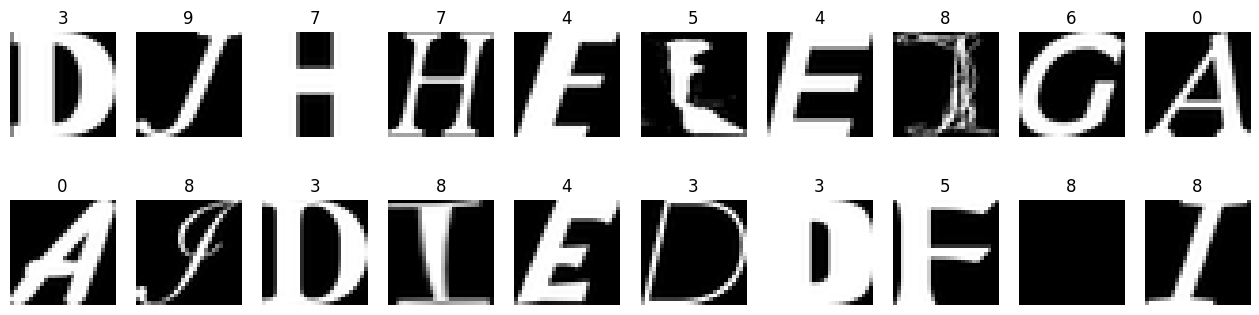

In [ ]:
# show some training images
plt.figure(figsize=(16, 4))

# fetch a batch of train images
image_batch, label_batch = next(iter(train_loader))

for i in range(20):
    image = image_batch[i]
    label = label_batch[i].item()
    plt.subplot(2, 10, i + 1)
    #image, label = train_loader.dataset.__getitem__(i)
    plt.imshow(image.squeeze().numpy(),cmap='gray')
    plt.axis('off')
    plt.title(label)

### Exploratory Data Analysis (EDA) after Preprocessing

1. **Class Distribution:**  
   The class more or less seem to be balanced, where each class have roughly same number of training samples.

2. **Image Shape and Type:**  
   Each image has been converted to a PyTorch tensor of shape `[1, 28, 28]` (channels x height x width), which is the format expected by the CNN.

3. **Pixel Value Range:**  
   After normalization, pixel values lie between -1 and 1. This ensures stable training and faster convergence.

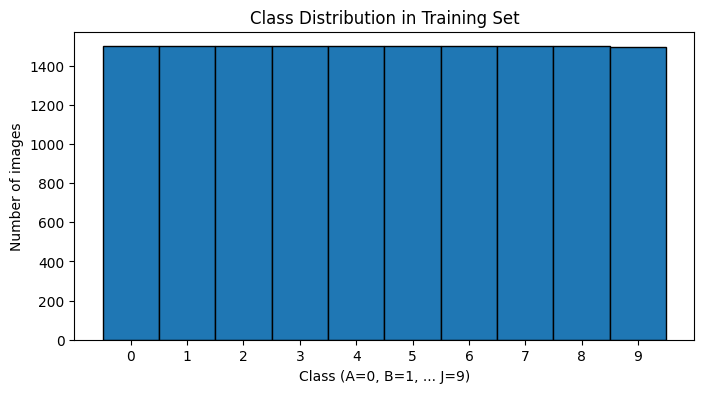

Example image shape: <built-in method size of Tensor object at 0x7f1f61b00d70>
Example image type: <class 'torch.Tensor'>
Batch pixel min: -1.0
Batch pixel max: 1.0
Batch pixel mean: -0.1290191113948822


In [ ]:
# Class distribution
labels = [item['label'] for item in ds['train']]
plt.figure(figsize=(8,4))
plt.hist(labels, bins=range(11), edgecolor='black', align='left')
plt.xticks(range(10))
plt.xlabel("Class (A=0, B=1, ... J=9)")
plt.ylabel("Number of images")
plt.title("Class Distribution in Training Set")
plt.show()

# Check image shape and type
print("Example image shape:", ds['train'][0]['image'].size)
print("Example image type:", type(ds['train'][0]['image']))

# Pixel value range in a batch
image_batch, label_batch = next(iter(train_loader))
print("Batch pixel min:", image_batch.min().item())
print("Batch pixel max:", image_batch.max().item())
print("Batch pixel mean:", image_batch.mean().item())


In [ ]:
print(f"Length of trainining samples:{ds['train'].shape}")
print(f"Length of test samples:{ds['test'].shape}")

Length of trainining samples:(14979, 2)
Length of test samples:(3745, 2)


### Visualizing Model Outputs

The following helper functions are used to **convert model outputs back into images** and **display them** for inspection.

- **`to_img(x)`**  
  Converts tensors (with pixel values in the range `[-1, 1]`) back to the standard image range `[0, 1]` and reshapes them into 28×28 format for visualization.

- **`display_images(in_raw, out_raw, n)`**  
  Displays a few sample images to visually compare **input images** with the **model's reconstructed or generated outputs**.  
  This helps us quickly check how well the model is learning to reproduce or generate realistic notMNIST letters.


In [ ]:
# Convert vector to image
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.view(x.size(0), 28, 28)
    return x


# Display images, n=max number of images to show
def display_images(in_raw, out_raw, n=1):
    out_raw = out_raw[:n]
    if in_raw is not None:
        in_raw = in_raw[:n]
        in_pic = to_img(in_raw.cpu().data).view(-1, 28, 28)
        plt.figure(figsize=(18, 6))
        for i in range(n):
            plt.subplot(1,n,i+1)
            plt.imshow(in_pic[i])
            plt.axis('off')
    out_pic = to_img(out_raw.cpu().data).view(-1, 28, 28)
    plt.figure(figsize=(18, 6))
    for i in range(n):
        plt.subplot(1,n,i+1)
        plt.imshow(out_pic[i])
        plt.axis('off')
    plt.show()

### Variational Autoencoder (VAE) Architecture

Below is the implementation of a **Variational Autoencoder (VAE)** built using PyTorch.  
The model learns a compressed latent representation of the notMNIST images and can also generate new samples by decoding points from the latent space.

- The **encoder** network compresses a 28×28 image into a pair of vectors:  
  - **μ (mean)** and **log σ² (log-variance)**, which define a Gaussian distribution in the latent space.
- The **sampler** uses the *reparameterization trick* to draw random latent vectors `z ~ N(μ, σ²)` in a differentiable way, allowing gradients to flow through the stochastic step.
- The **decoder** reconstructs the image from the latent vector `z` using a symmetric feedforward network and outputs values in the range `[-1, 1]` via a `tanh` activation.

The model also includes a helper function:
- **`generate(N)`** — samples random latent vectors from a standard normal distribution and decodes them into new, unseen images.


In [ ]:
class VAE(nn.Module):
    def __init__(self, d=50):
        super().__init__()
        self.d = d #latent dimension
        self.input_dim=28*28

        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, d ** 2),
            nn.ReLU(),
            nn.Linear(d ** 2, d * 2) # we have mean and variance, each is d-dim vector
        )

        self.decoder = nn.Sequential(
            nn.Linear(d, d ** 2),
            nn.ReLU(),
            nn.Linear(d ** 2, self.input_dim),
            nn.Tanh()
        )

    def sampler(self, mu, logvar):
        if self.training:
            std = logvar.mul(0.5).exp_()
            eps = std.new_empty(std.size()).normal_()
            return eps.mul_(std).add_(mu)
        else:
            return mu

    def forward(self, x):
        mu_logvar = self.encoder(x.view(-1, self.input_dim)).view(-1, 2, self.d)
        mu = mu_logvar[:, 0, :]
        logvar = mu_logvar[:, 1, :]
        z = self.sampler(mu, logvar)
        return self.decoder(z), mu, logvar

    def generate(self, N=10):
        z = torch.randn((N, self.d)).to(device)
        gen_img = self.decoder(z)
        return gen_img

### VAE Loss Function

The loss function for the Variational Autoencoder balances two objectives:

1. **Reconstruction Loss**  
   Measures how accurately the decoder can reconstruct the input image from its latent representation.  
   Here, we use **Mean Squared Error (MSE)** instead of Binary Cross Entropy, since the notMNIST dataset’s pixel values are continuous and normalized to `[-1, 1]`.

2. **KL Divergence (KLD)**  
   Regularizes the latent space by forcing the learned distribution `q(z|x)` (parameterized by μ and σ) to stay close to the standard normal prior `p(z) = N(0, I)`.  
   This prevents the model from simply memorizing images and ensures a smooth, continuous latent space for interpolation.

The final loss combines these two terms:
$$
\text{Loss} = \text{Reconstruction Loss} + \beta \times \text{KL Divergence}
$$
The **β parameter** allows control over the trade-off between reconstruction fidelity and latent space regularization.


In [ ]:
def loss_function(x_hat, x, mu, logvar, beta=1):
    #recon_loss = nn.functional.binary_cross_entropy(
    recon_loss = nn.functional.mse_loss(
        x_hat, x.view(-1, 784), reduction='sum'
    )
    KLD = 0.5 * torch.sum(logvar.exp() - logvar - 1 + mu.pow(2))

    return recon_loss + beta * KLD

### Training the Variational Autoencoder

We now train the VAE using the notMNIST dataset.

- The **latent dimension** (`latent_dim = 20`) controls the size of the compressed representation learned by the encoder.  
- The model is optimized using **Adam** with a small learning rate (`5e-4`) for stable convergence.  
- We train for **50 epochs**, alternating between training and evaluation on the test set.

During each epoch:
1. **Training Phase**  
   - The model encodes each image into a latent distribution (mean and variance).  
   - It then reconstructs the image and computes the combined **VAE loss** (reconstruction + KL divergence).  
   - Gradients are backpropagated, and the optimizer updates the parameters.

2. **Evaluation Phase**  
   - The model switches to evaluation mode (`model.eval()`), generating reconstructions on the test data.  
   - We compute the average test loss and record the latent means and variances for later visualization.

3. **Visualization**  
   - After each epoch, a few **original vs reconstructed images** are displayed to qualitatively monitor how well the model is learning.

Over time, we expect the reconstructions to become sharper and more recognizable as the model learns an effective latent space.


====> Test set loss: 682.1686


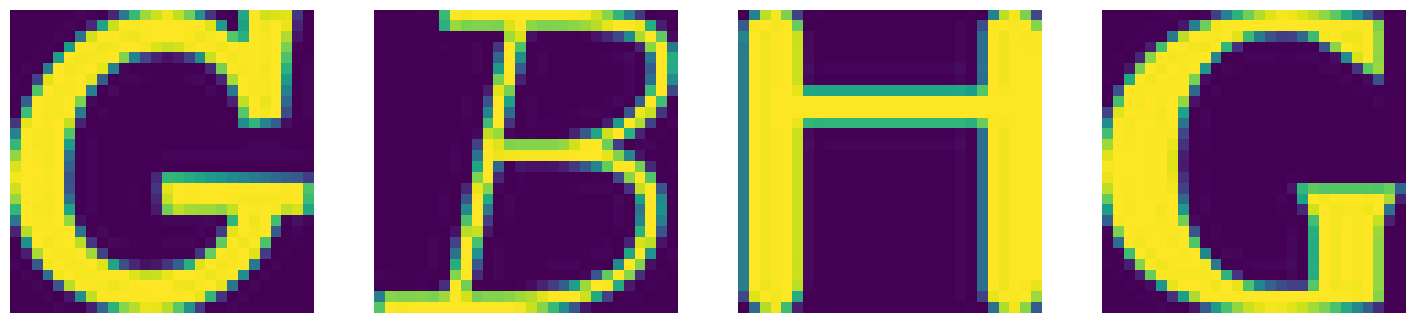

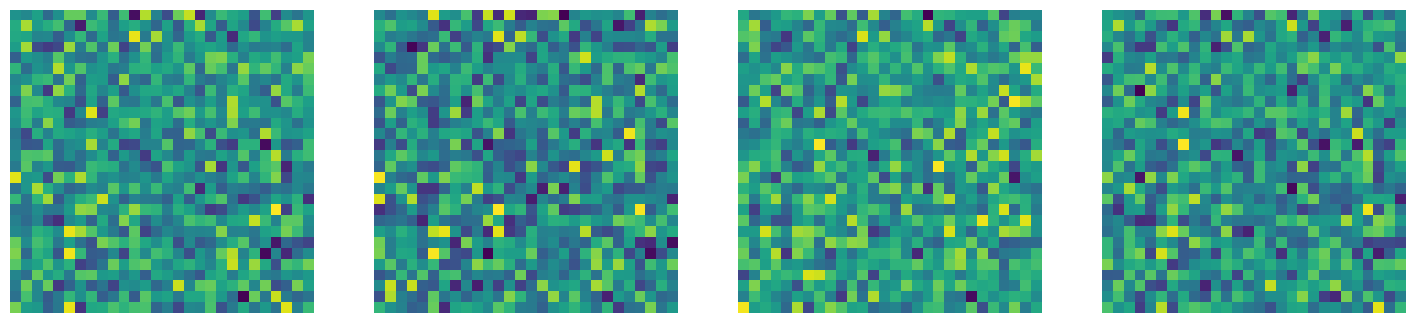

====> Epoch: 1 Average train loss: 277.1035
====> Test set loss: 171.0692


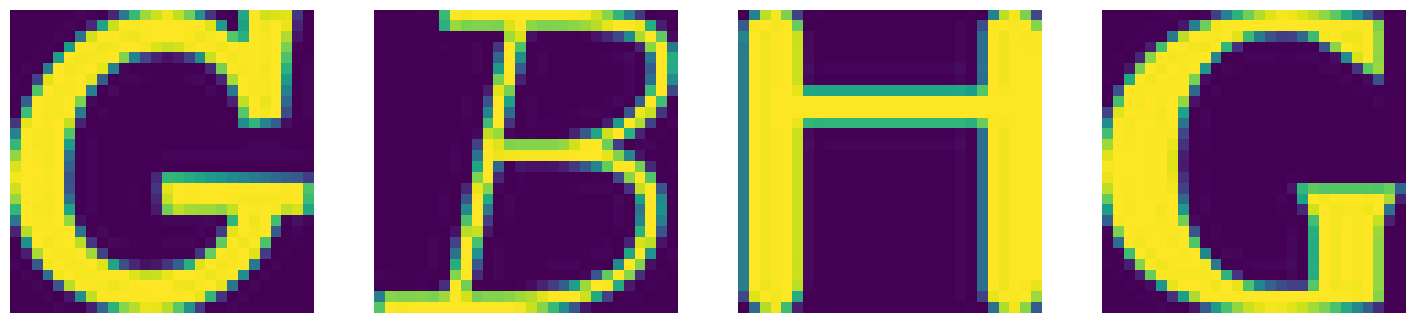

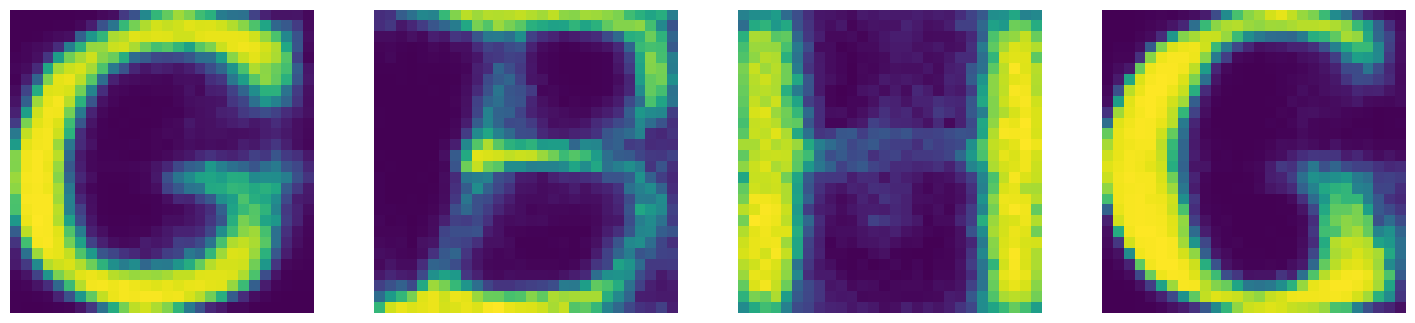

====> Epoch: 2 Average train loss: 162.0621
====> Test set loss: 143.3691


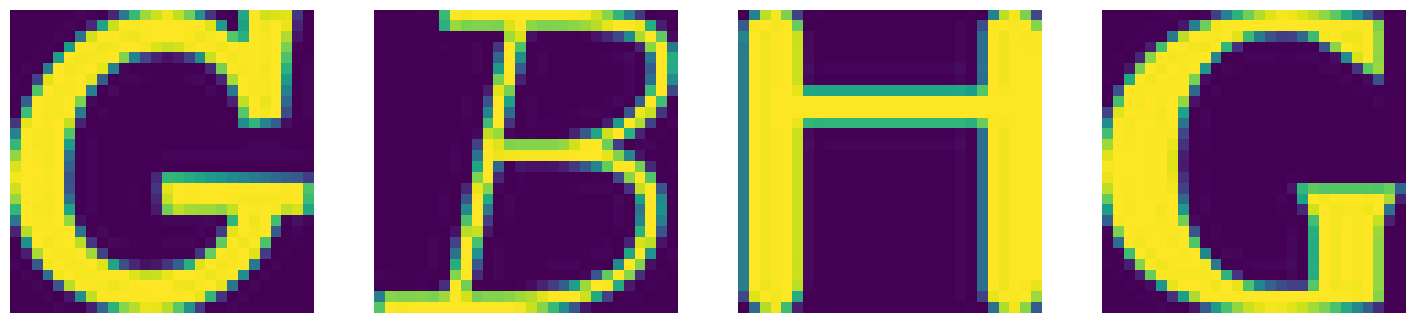

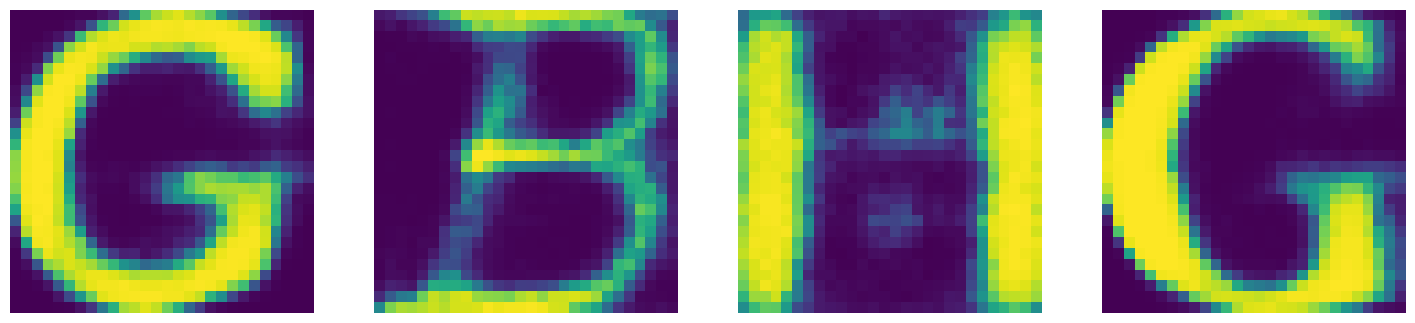

====> Epoch: 3 Average train loss: 144.3551
====> Test set loss: 132.4377


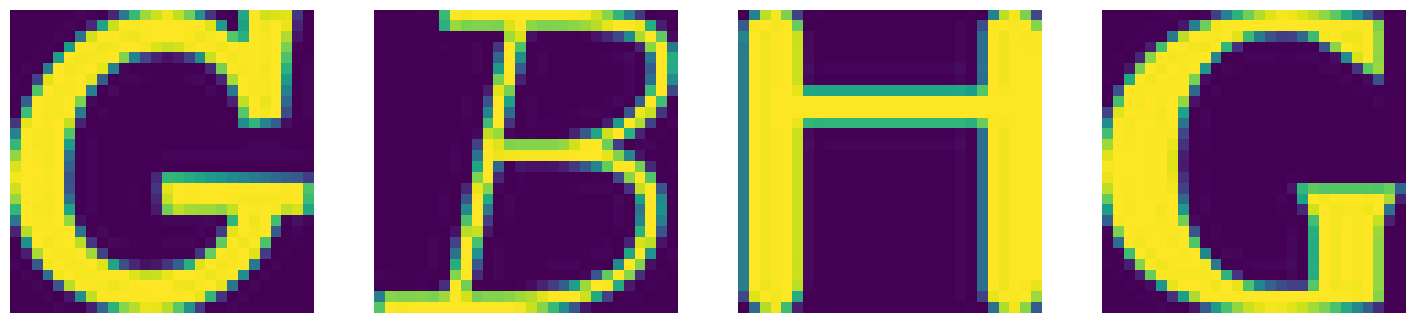

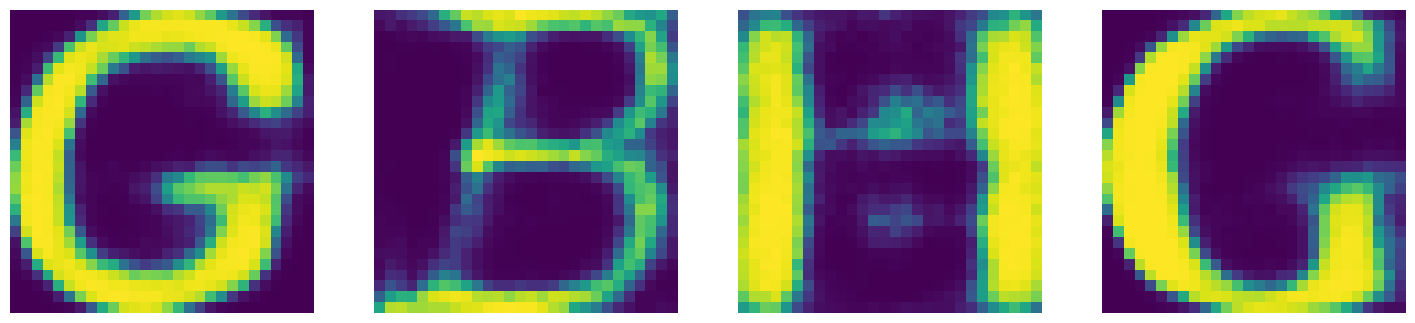

====> Epoch: 4 Average train loss: 135.8708
====> Test set loss: 126.4967


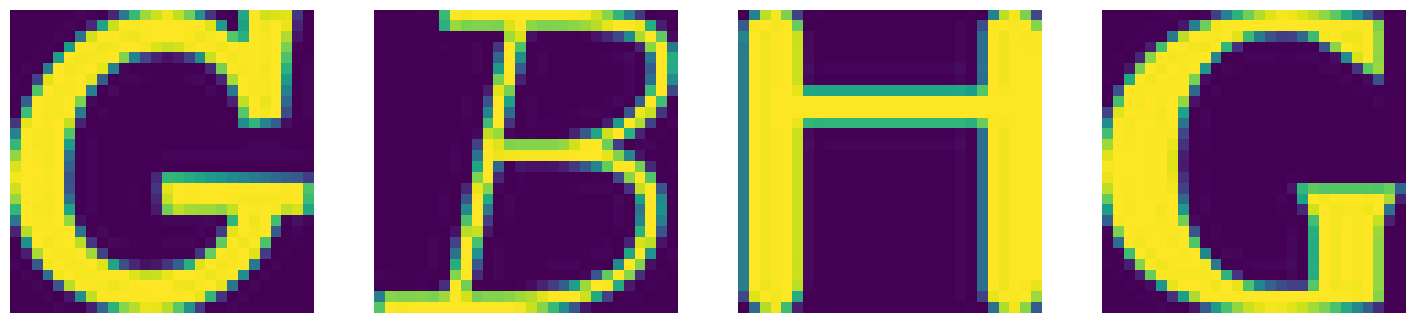

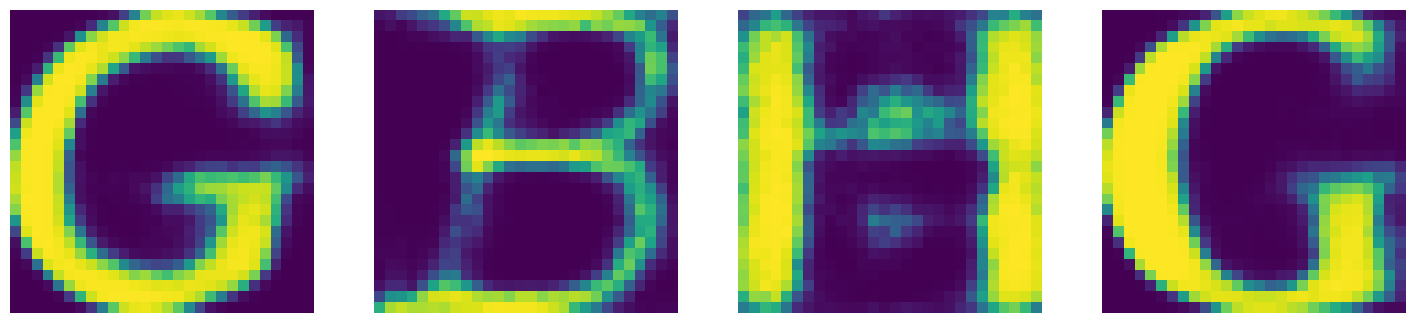

====> Epoch: 5 Average train loss: 131.0846
====> Test set loss: 123.5356


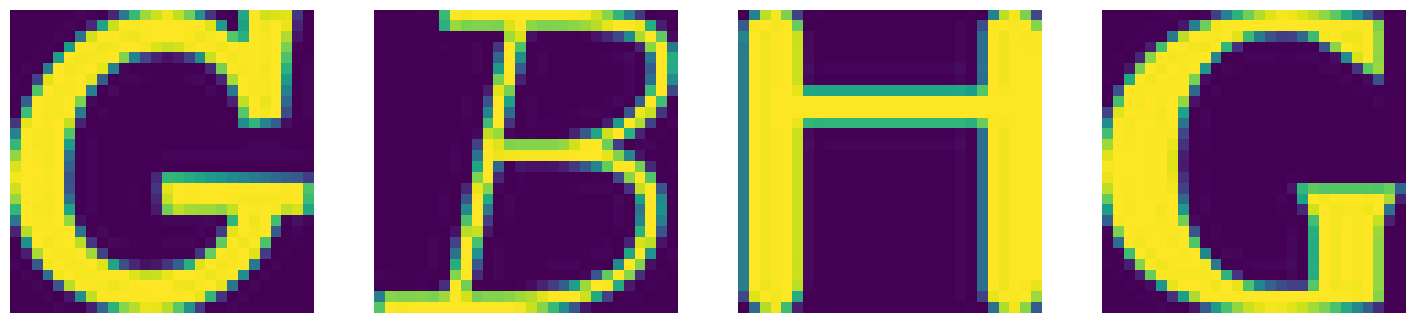

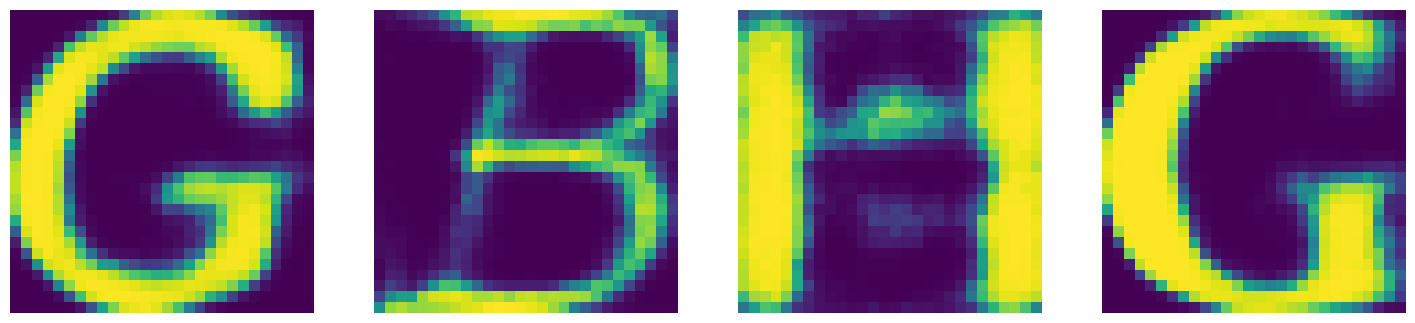

====> Epoch: 6 Average train loss: 127.2958
====> Test set loss: 120.6179


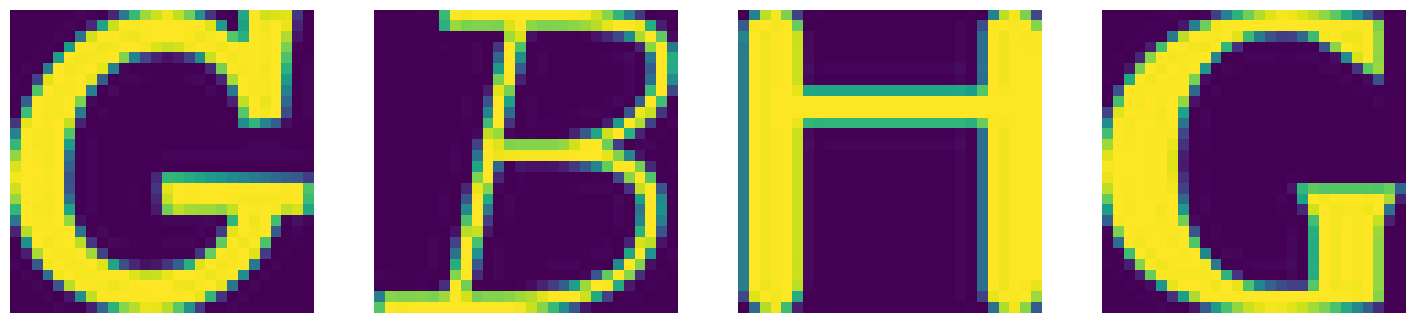

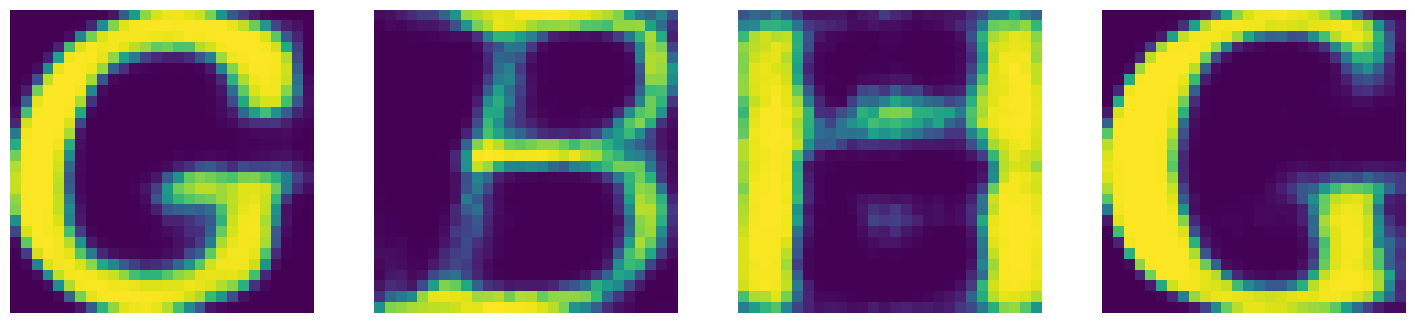

====> Epoch: 7 Average train loss: 124.4919
====> Test set loss: 119.9667


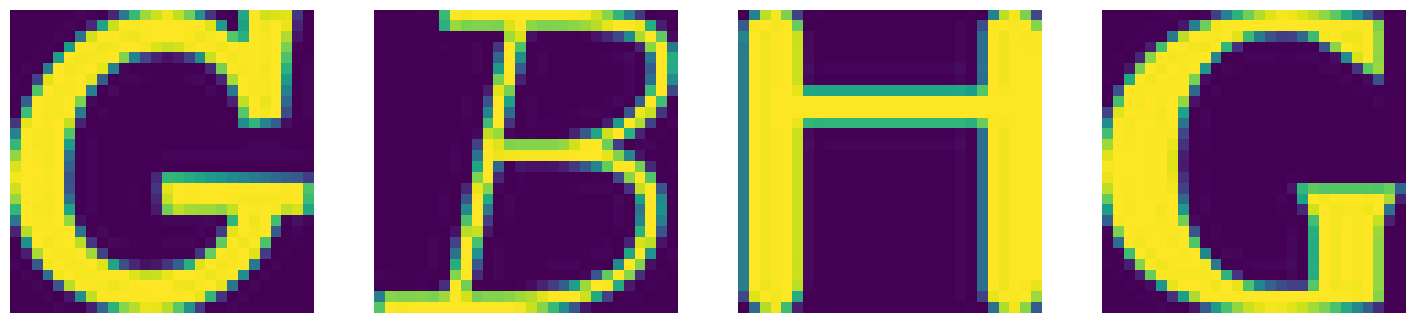

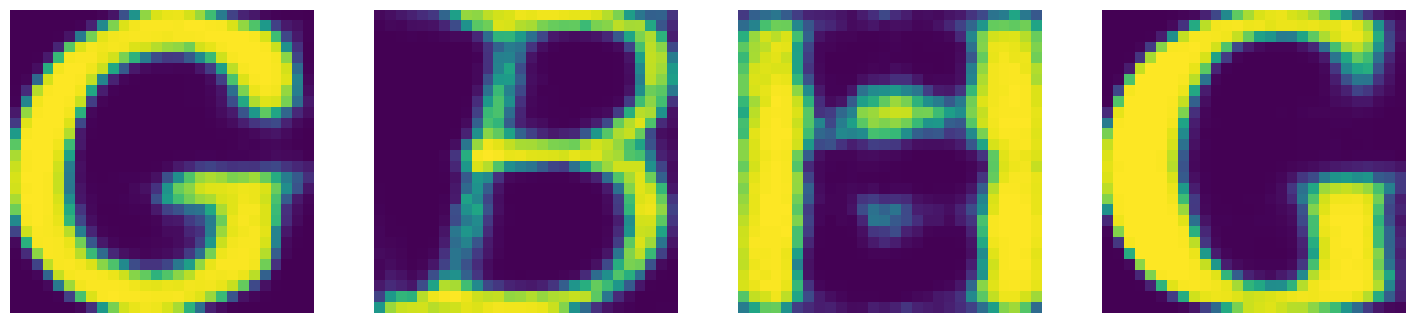

====> Epoch: 8 Average train loss: 122.3492
====> Test set loss: 117.8829


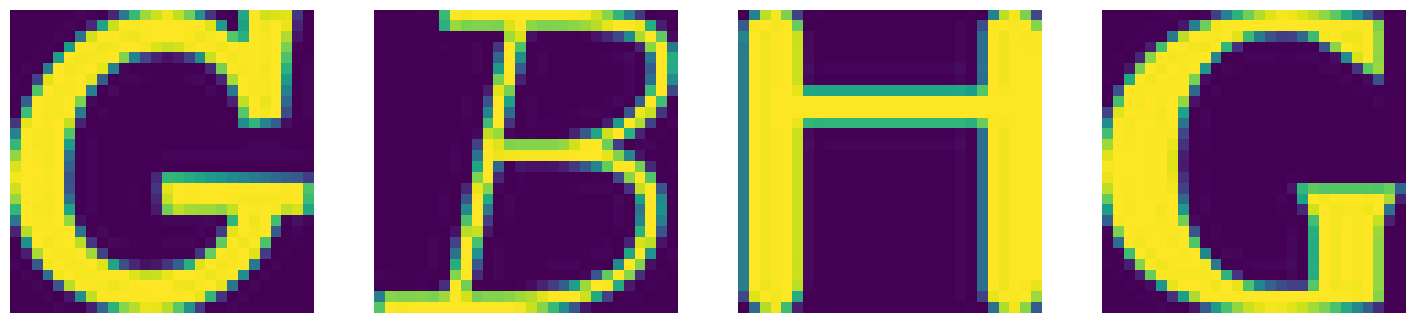

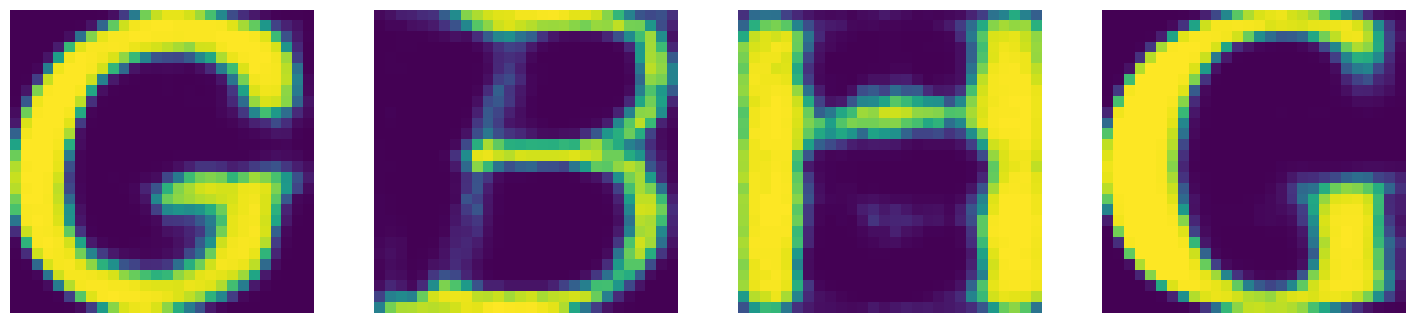

====> Epoch: 9 Average train loss: 120.2969
====> Test set loss: 114.7687


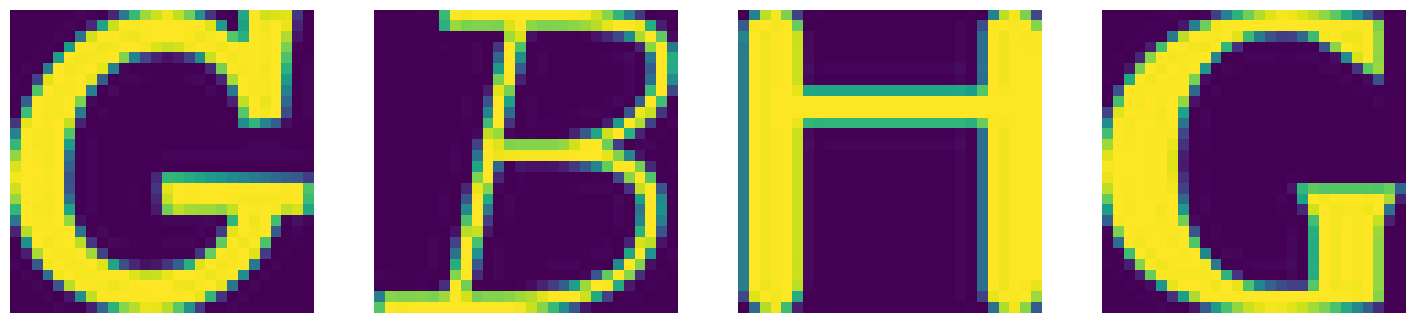

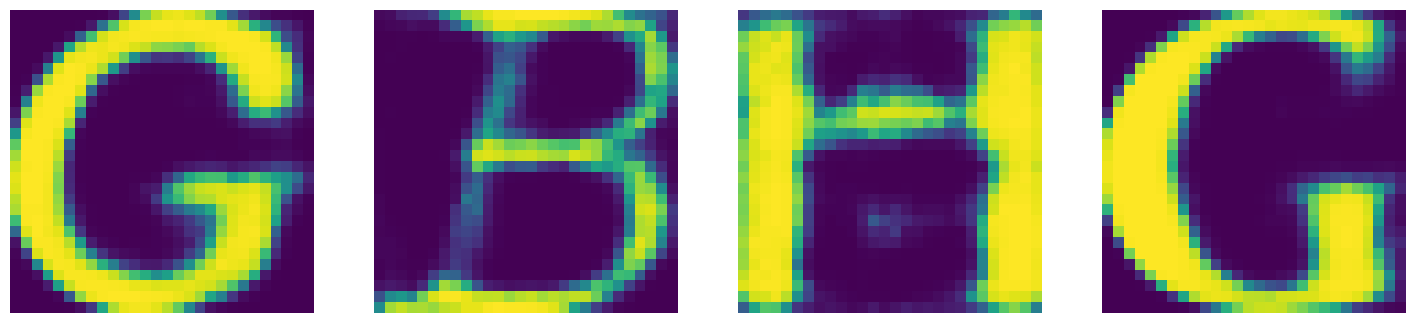

====> Epoch: 10 Average train loss: 118.6557
====> Test set loss: 113.9405


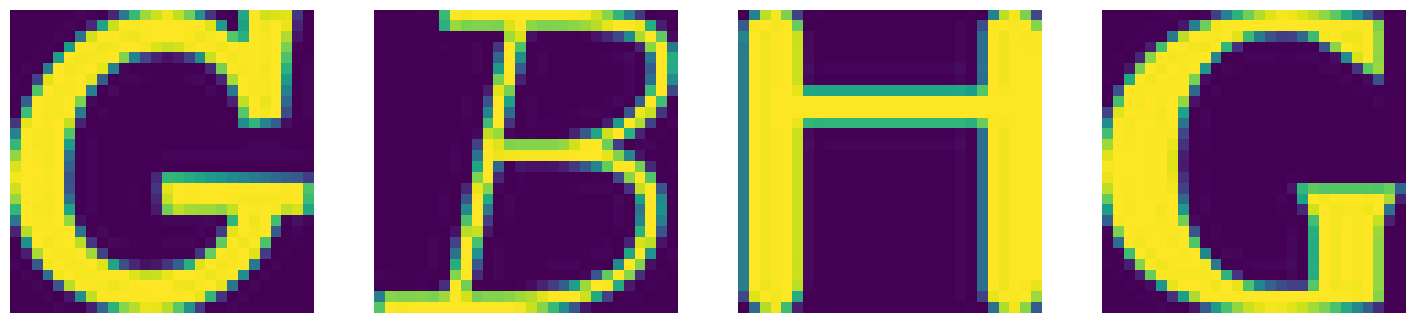

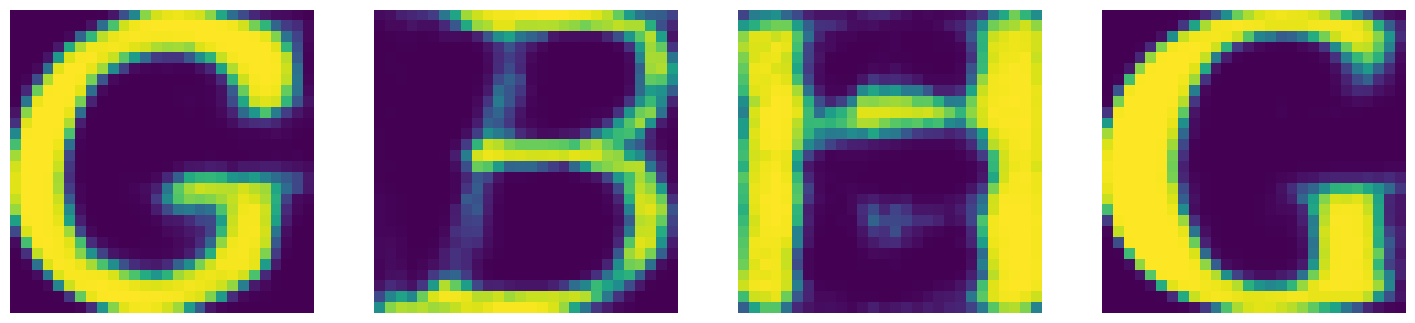

====> Epoch: 11 Average train loss: 117.3100
====> Test set loss: 114.2086


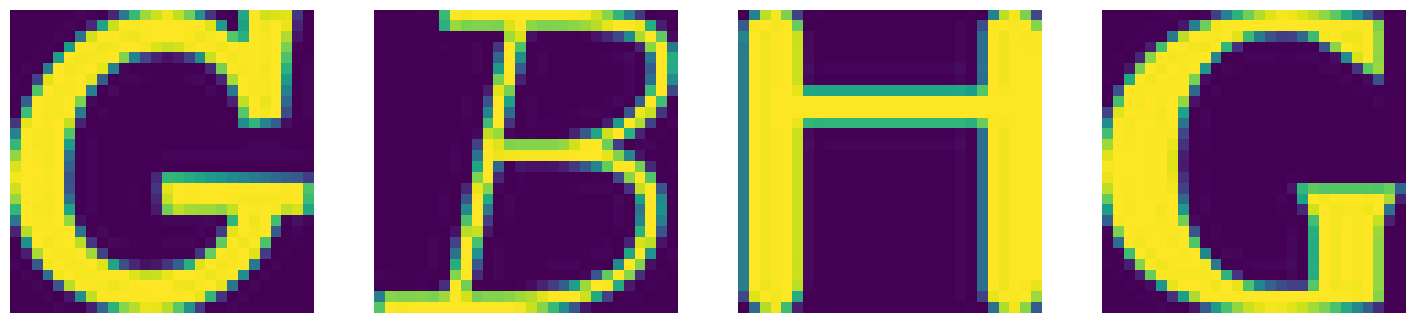

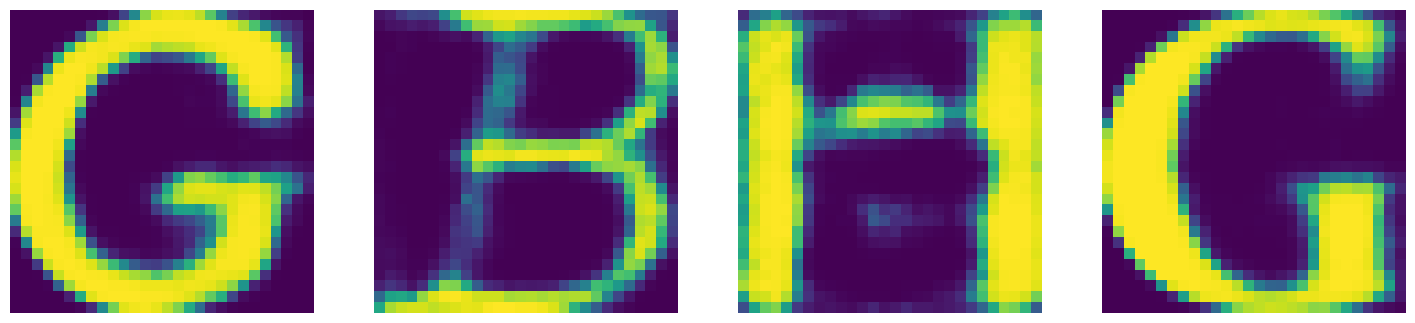

====> Epoch: 12 Average train loss: 116.2320
====> Test set loss: 113.0649


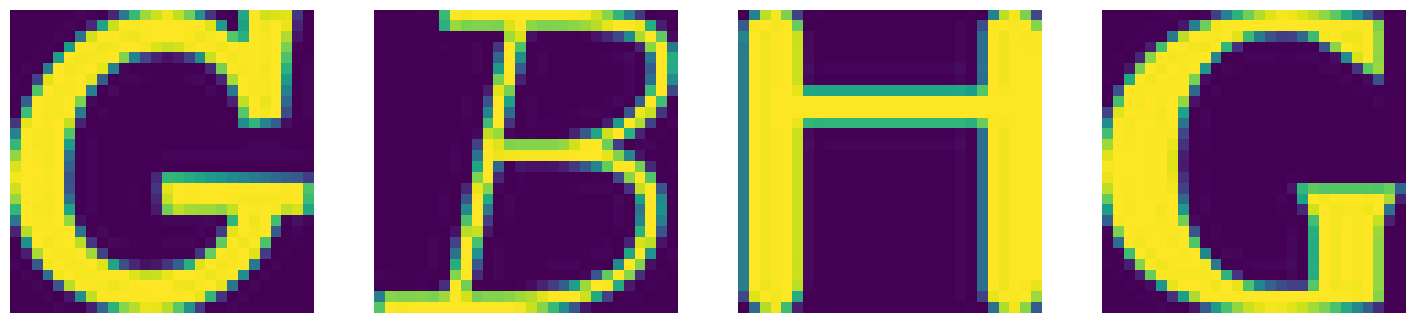

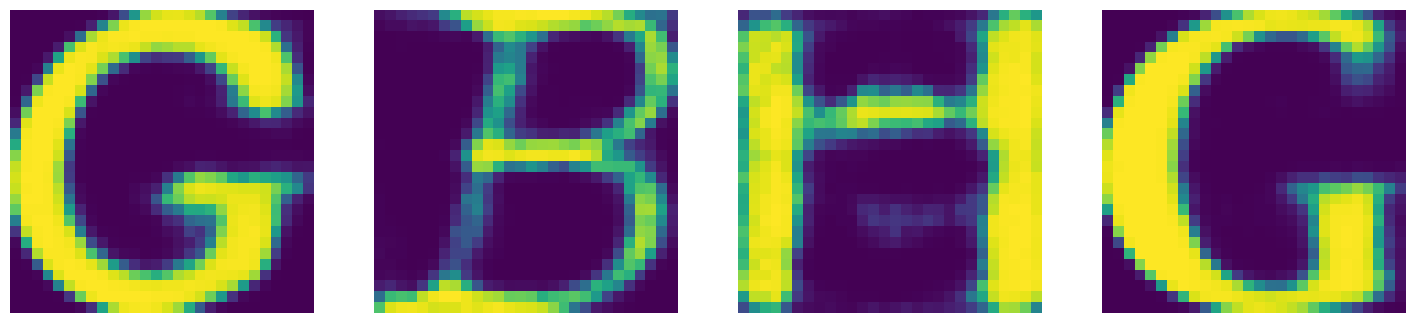

====> Epoch: 13 Average train loss: 114.9241
====> Test set loss: 110.7484


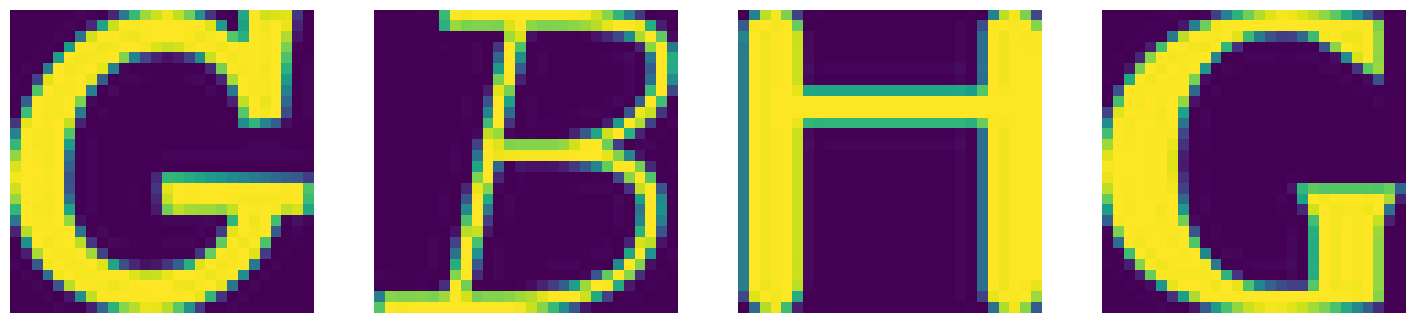

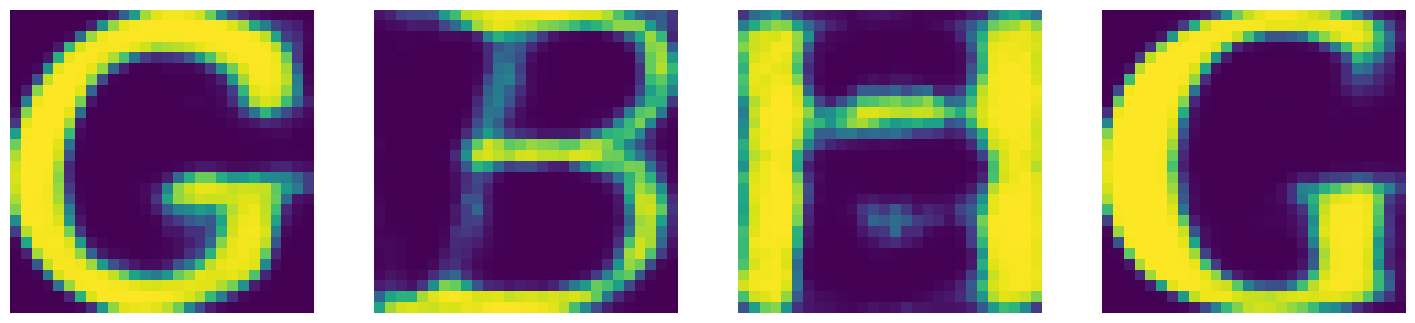

====> Epoch: 14 Average train loss: 113.9254
====> Test set loss: 110.3883


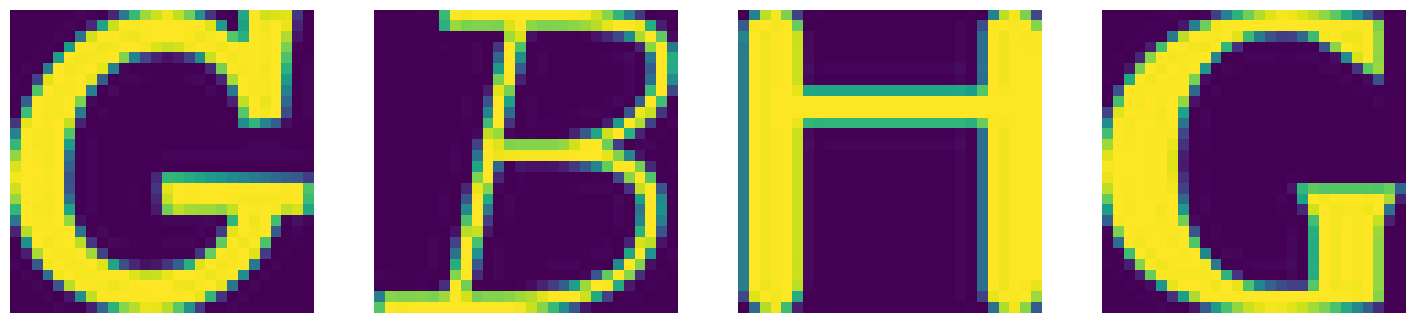

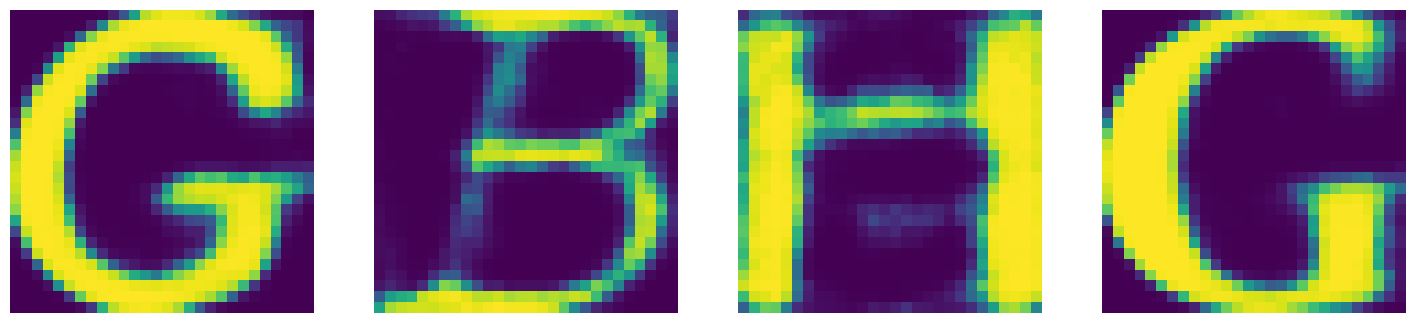

====> Epoch: 15 Average train loss: 112.9842
====> Test set loss: 110.0343


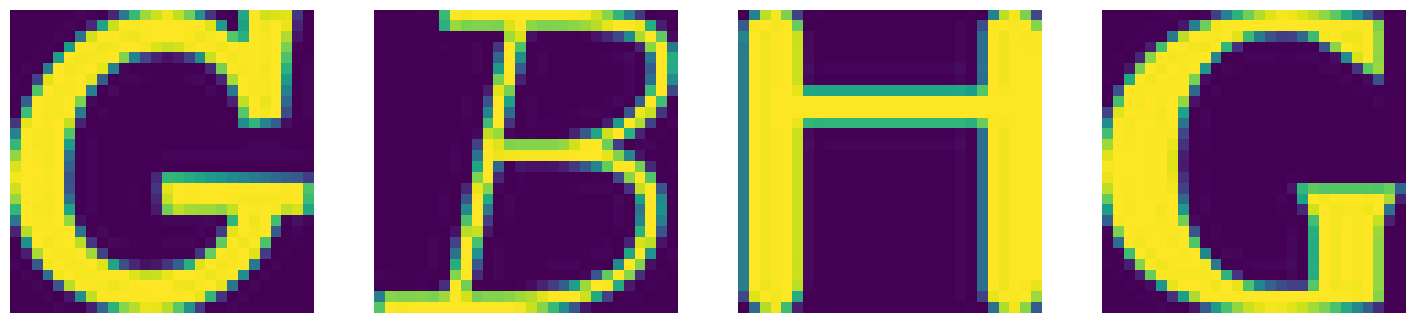

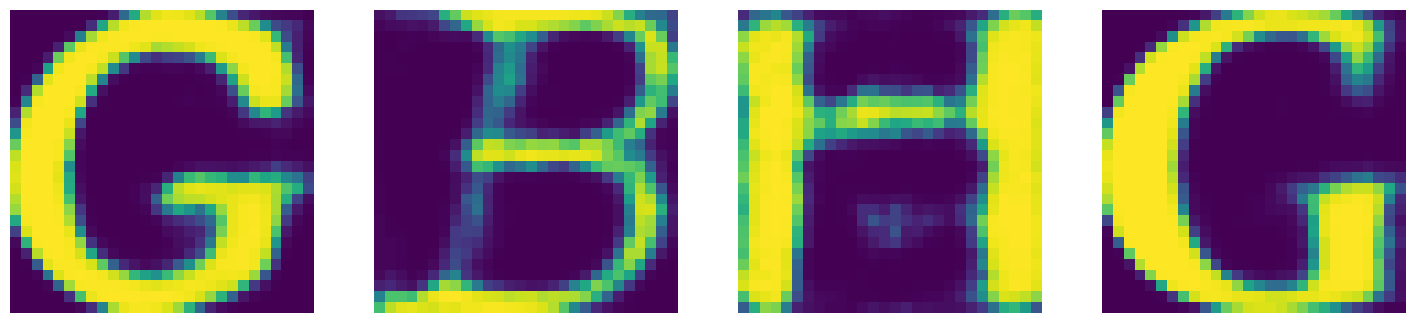

====> Epoch: 16 Average train loss: 112.1608
====> Test set loss: 109.9030


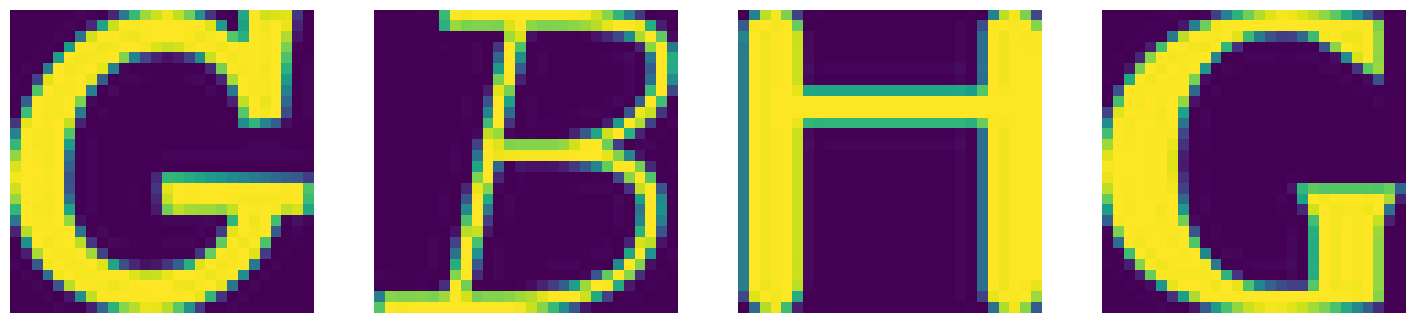

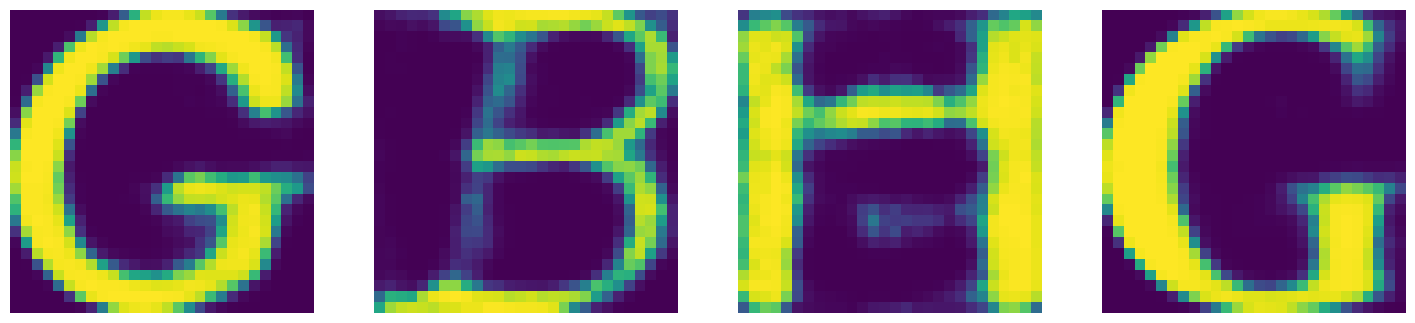

====> Epoch: 17 Average train loss: 111.5981
====> Test set loss: 110.3003


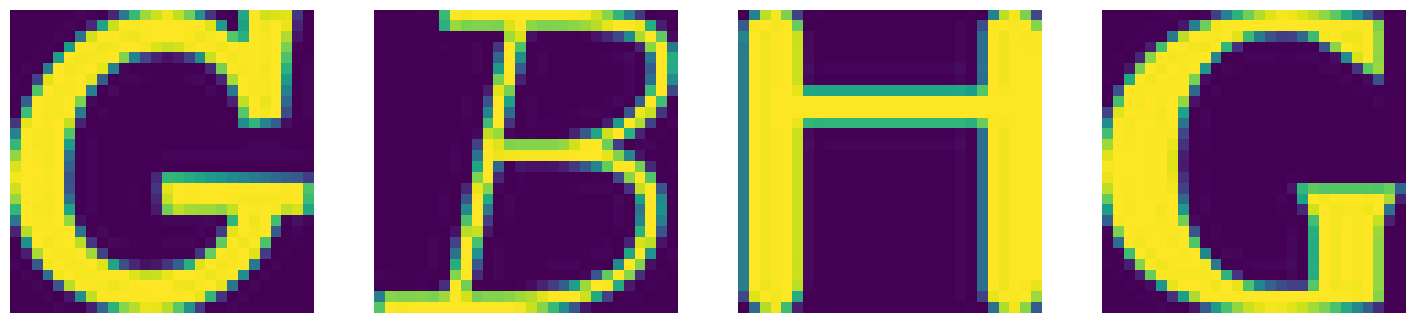

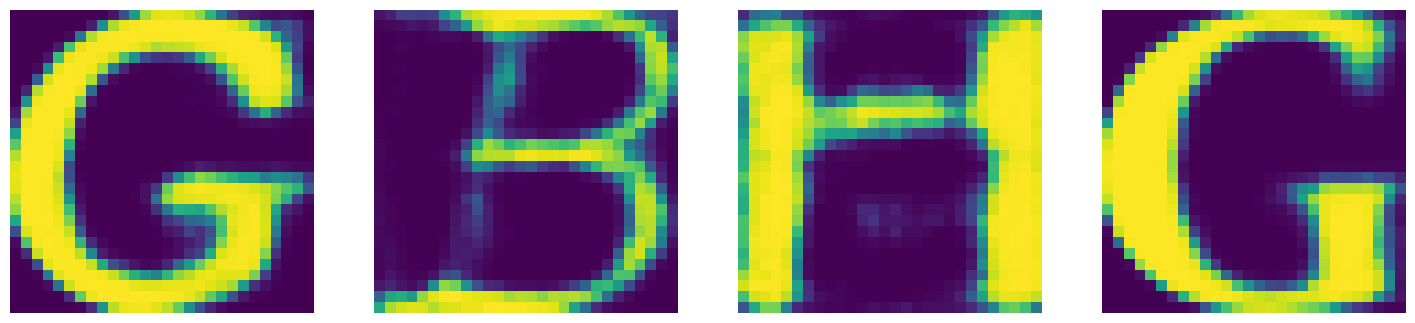

====> Epoch: 18 Average train loss: 110.8101
====> Test set loss: 108.2333


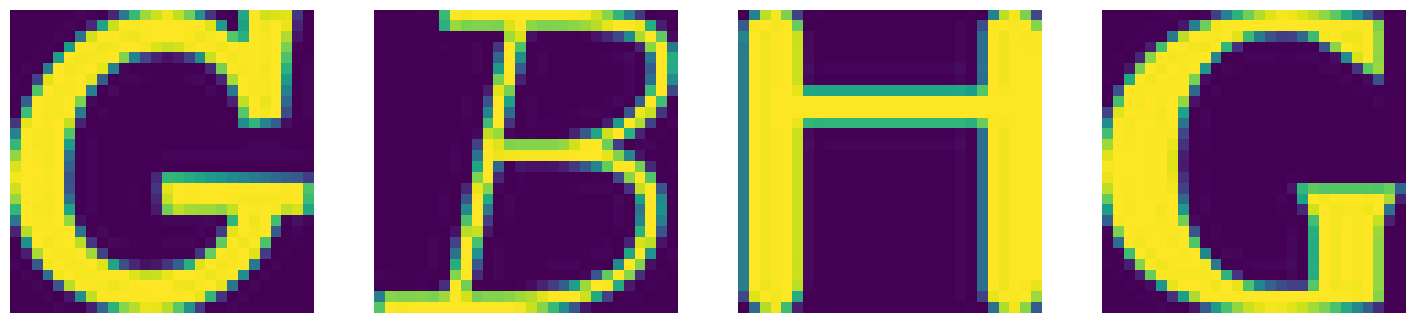

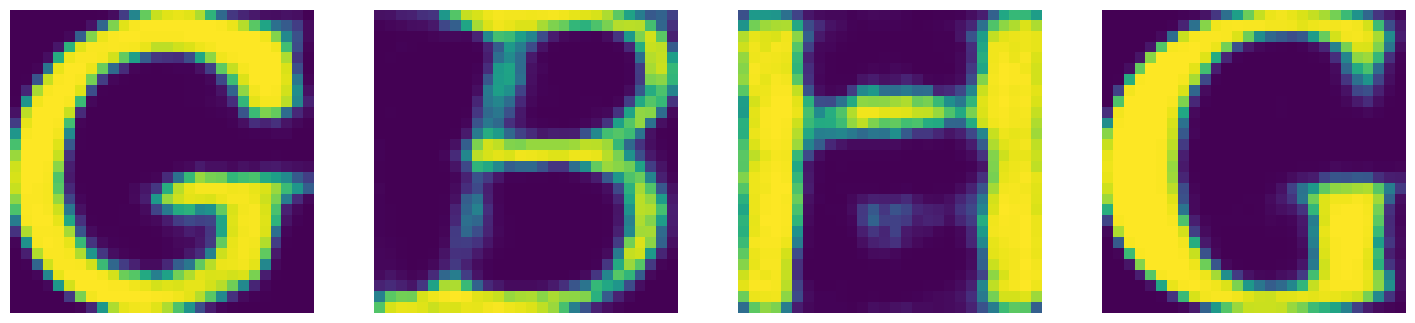

====> Epoch: 19 Average train loss: 110.2060
====> Test set loss: 108.6782


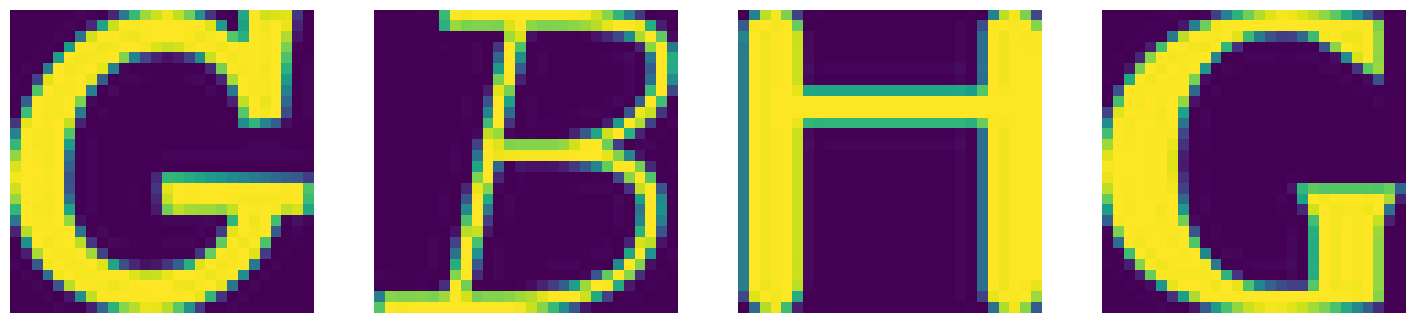

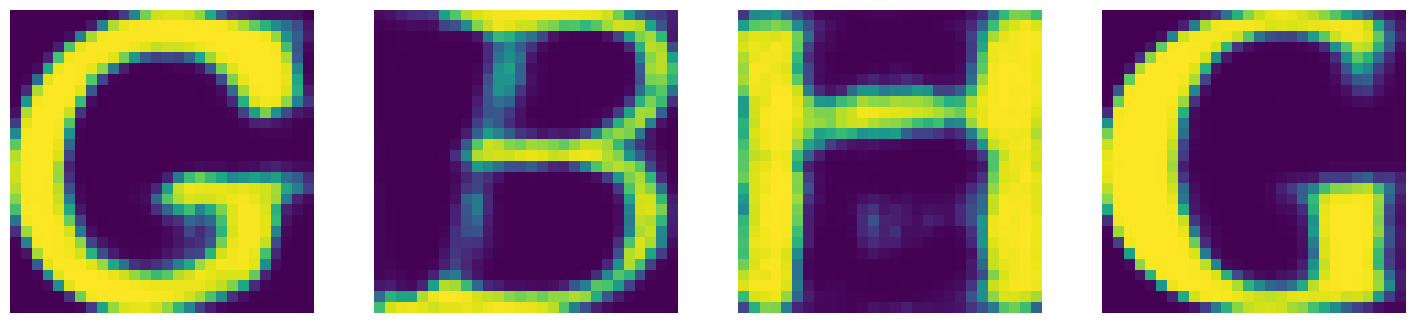

====> Epoch: 20 Average train loss: 109.6295
====> Test set loss: 108.7640


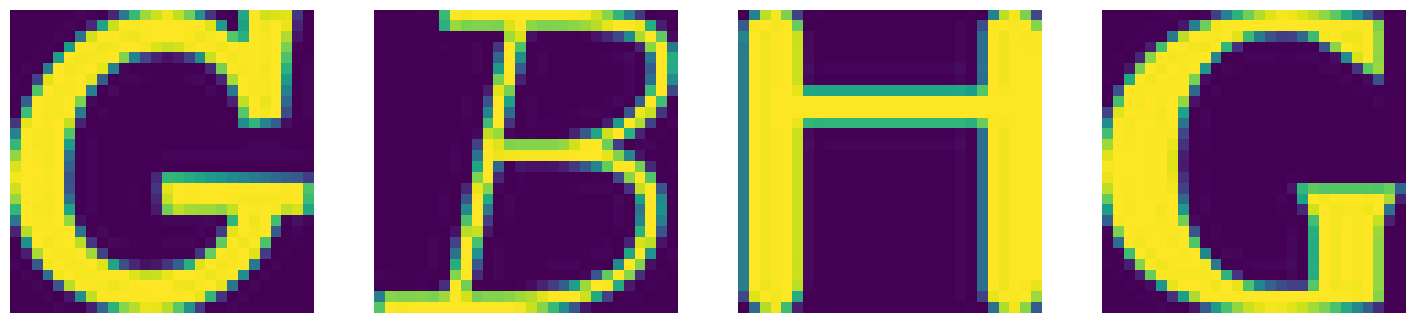

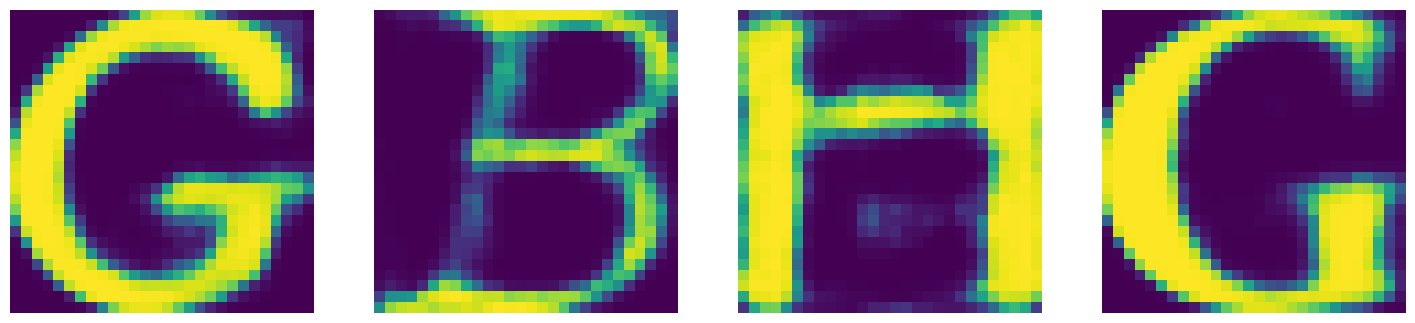

====> Epoch: 21 Average train loss: 108.9275
====> Test set loss: 107.2205


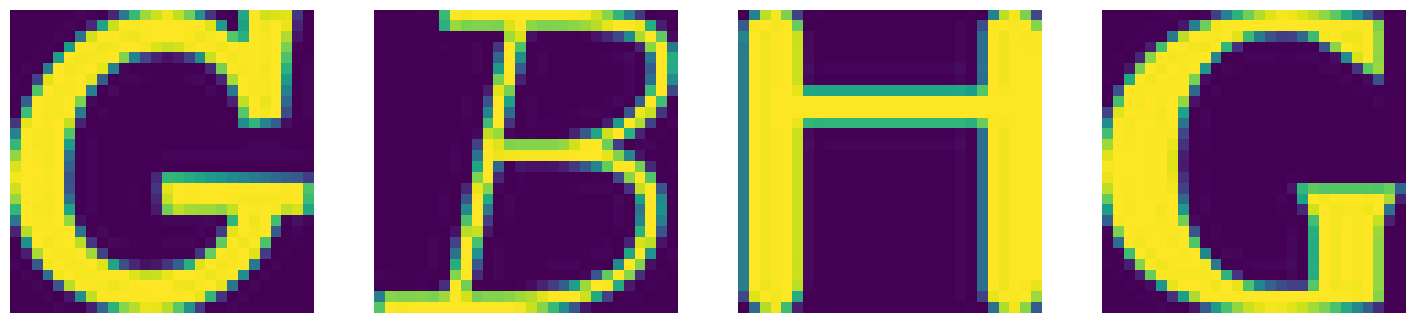

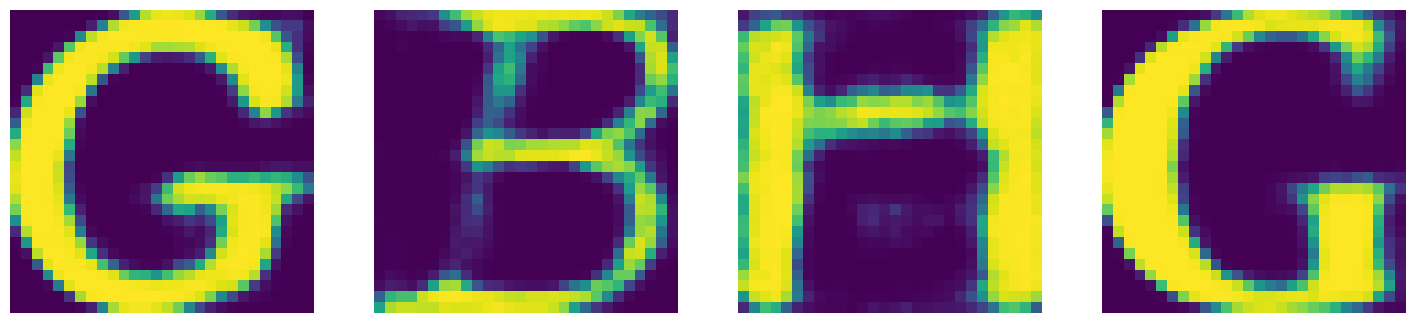

====> Epoch: 22 Average train loss: 108.6263
====> Test set loss: 107.6297


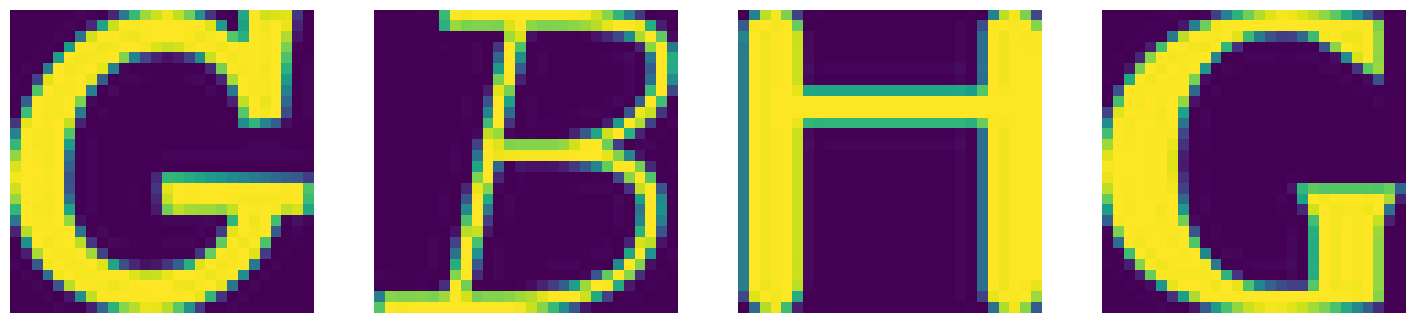

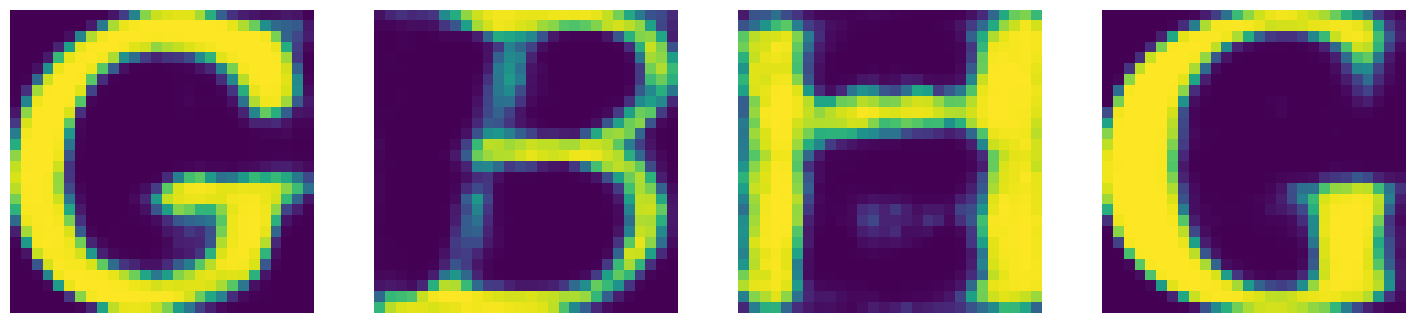

====> Epoch: 23 Average train loss: 108.1641
====> Test set loss: 106.8807


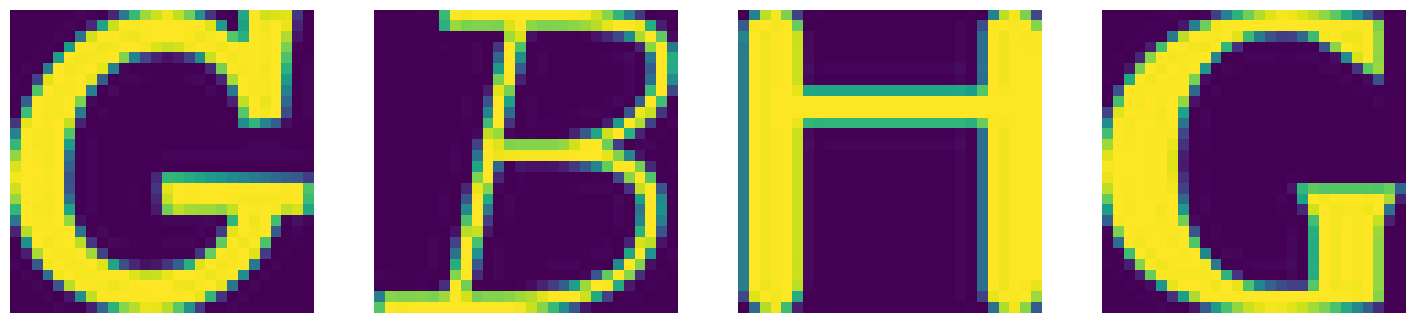

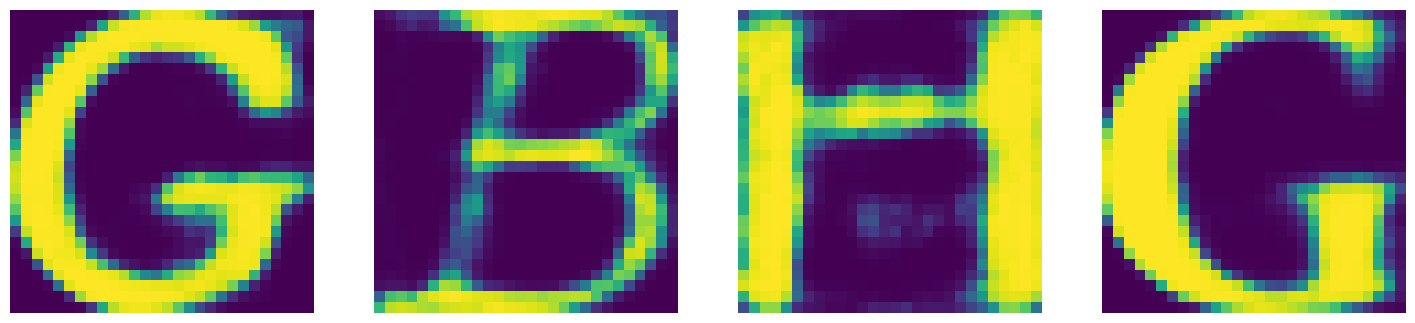

====> Epoch: 24 Average train loss: 107.6232
====> Test set loss: 107.8436


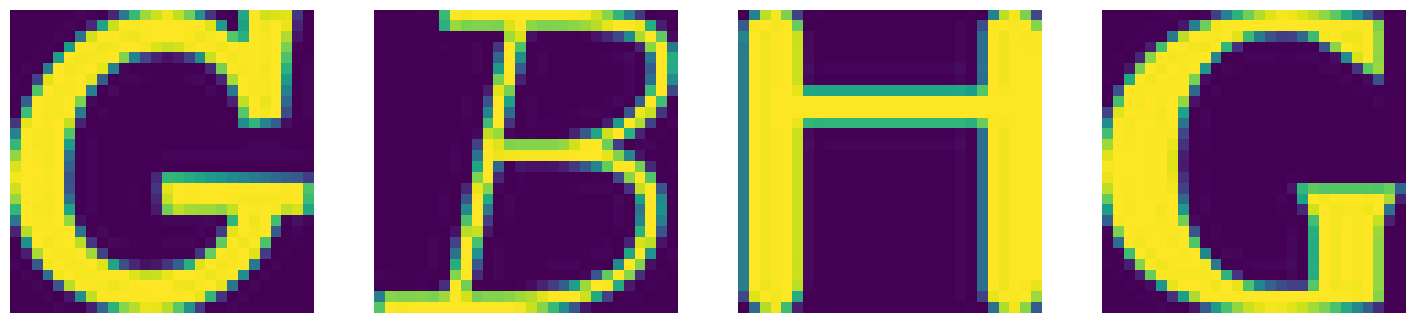

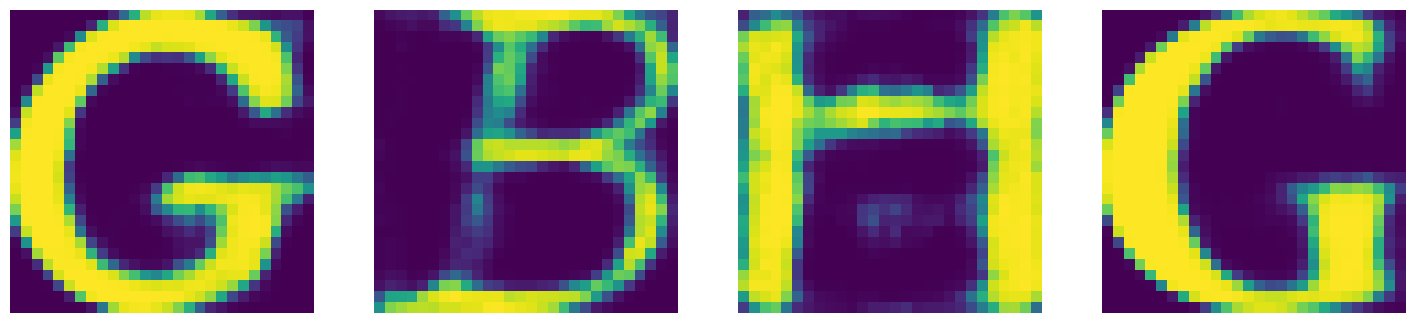

====> Epoch: 25 Average train loss: 107.0619
====> Test set loss: 106.2182


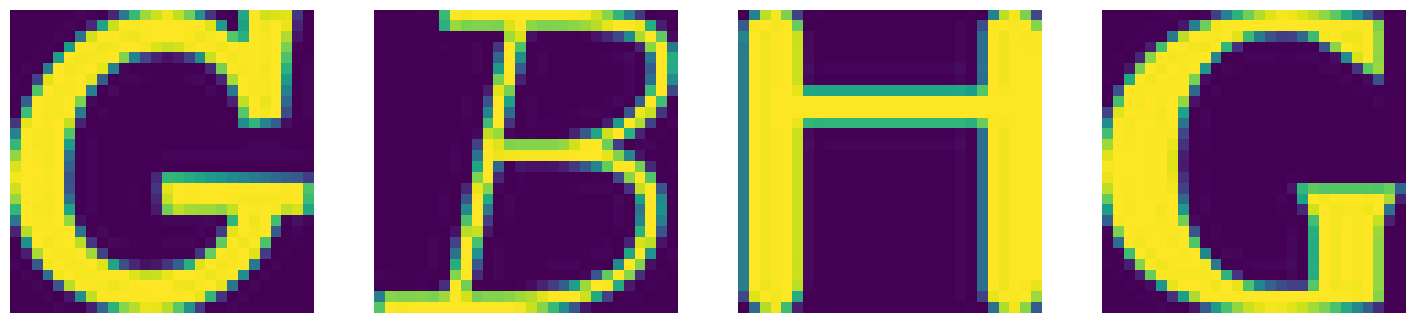

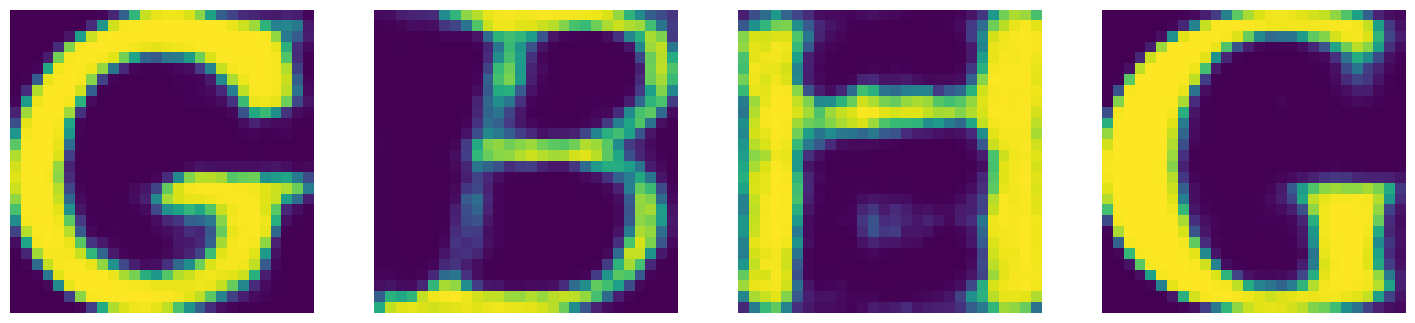

====> Epoch: 26 Average train loss: 106.5996
====> Test set loss: 106.1125


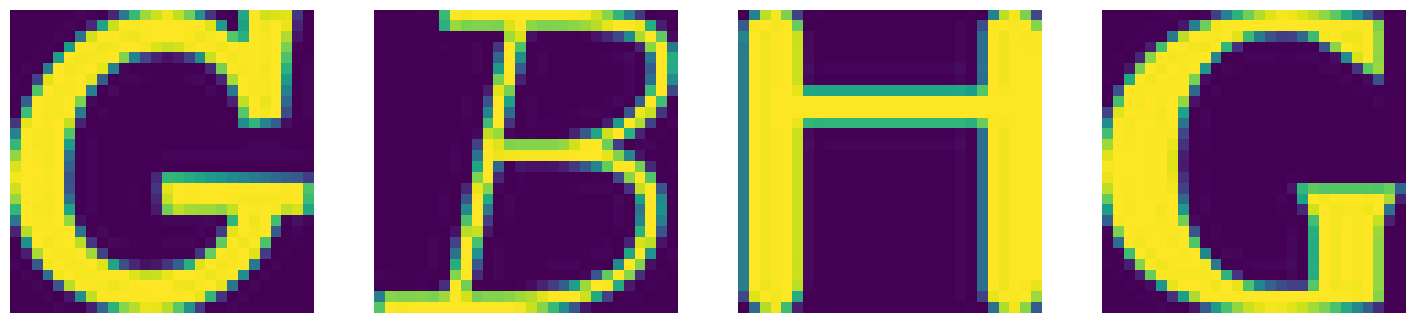

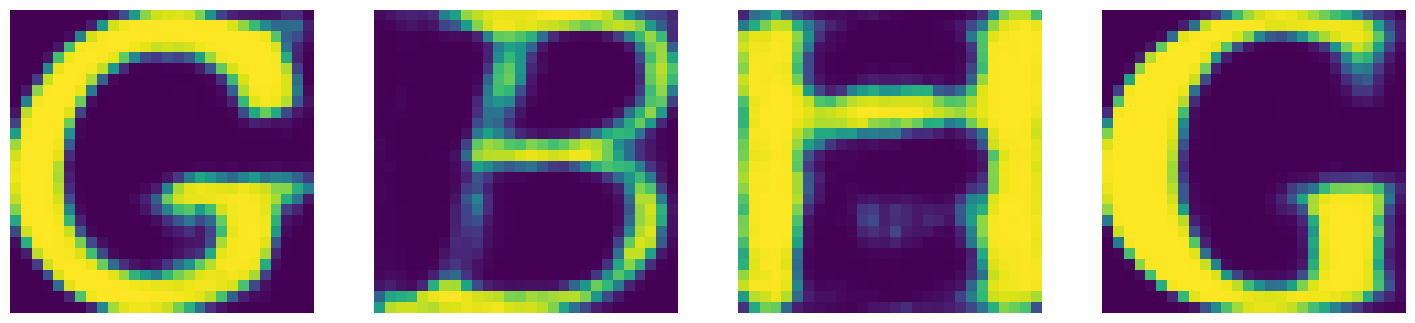

====> Epoch: 27 Average train loss: 106.4205
====> Test set loss: 106.3672


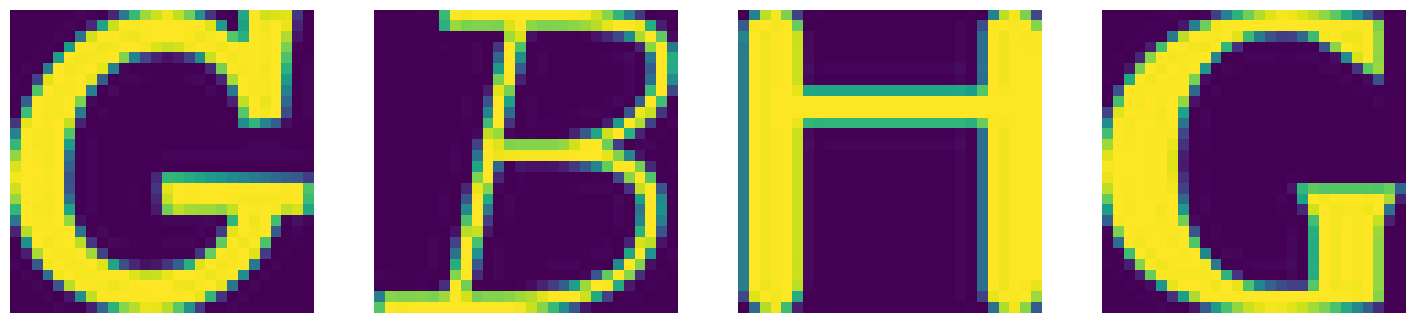

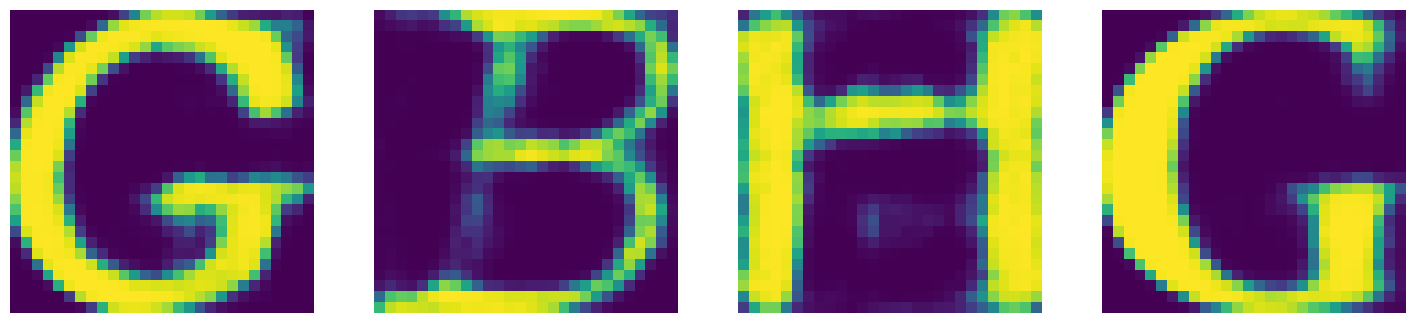

====> Epoch: 28 Average train loss: 106.0388
====> Test set loss: 105.7516


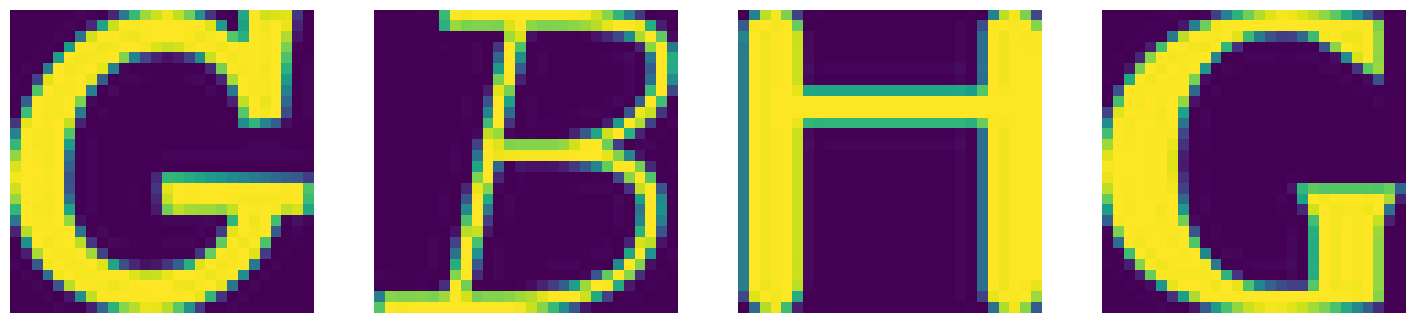

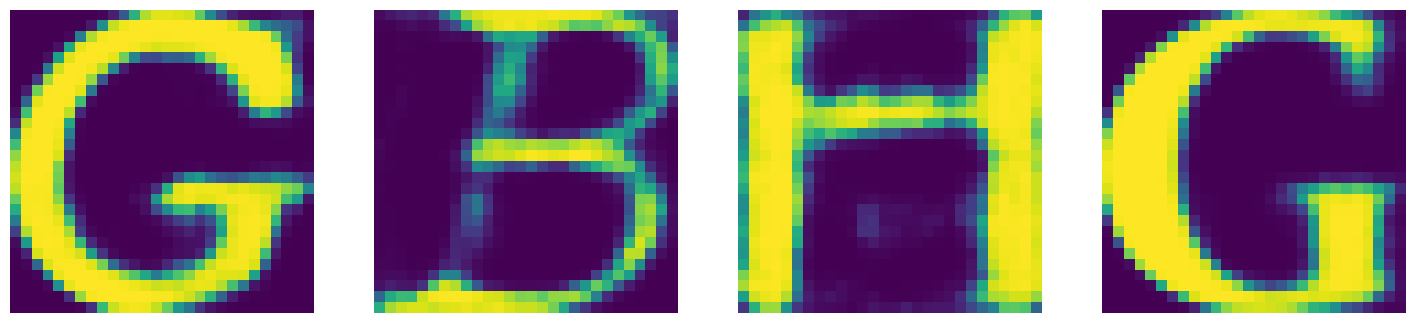

====> Epoch: 29 Average train loss: 105.7170
====> Test set loss: 105.6760


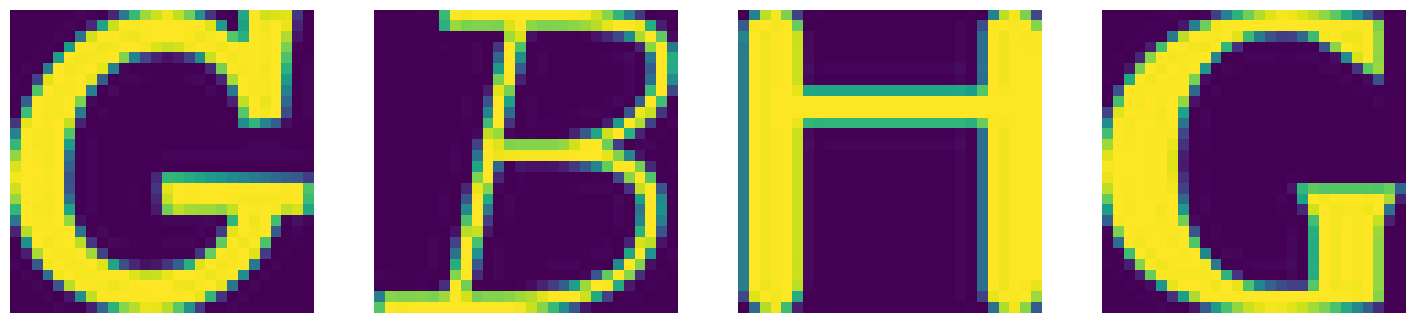

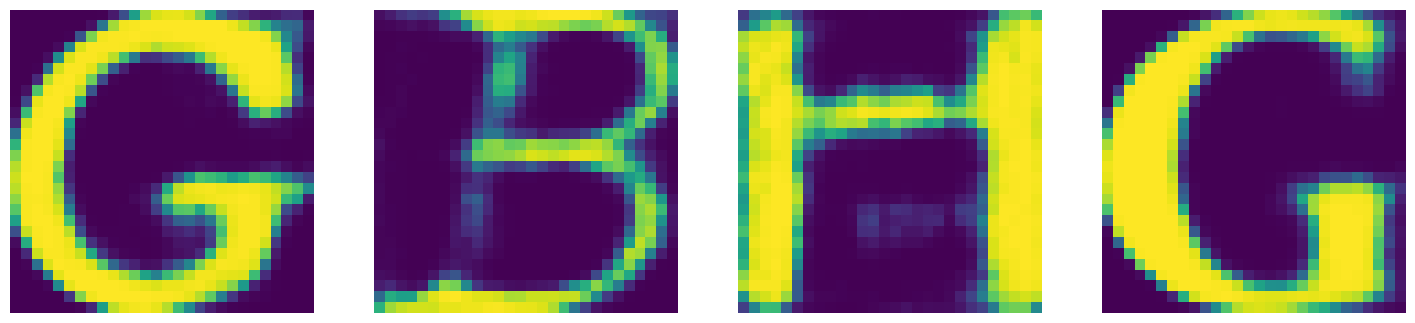

====> Epoch: 30 Average train loss: 105.3518
====> Test set loss: 106.5325


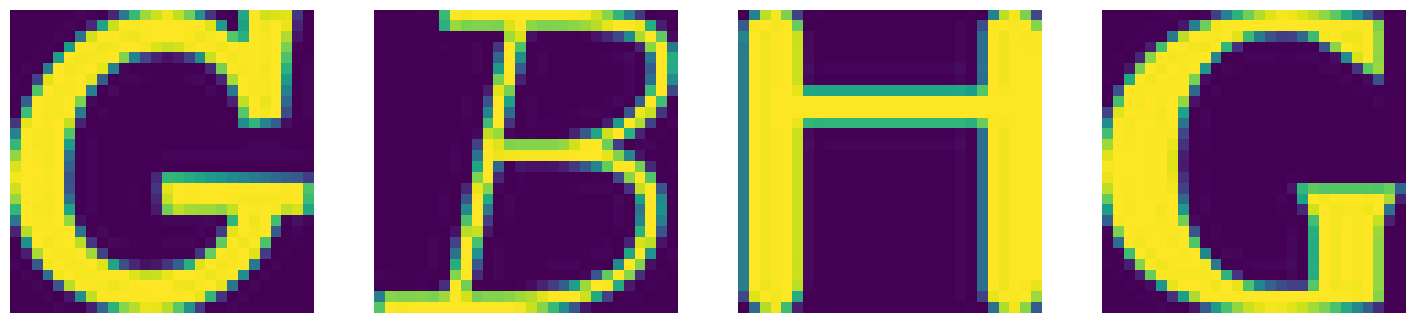

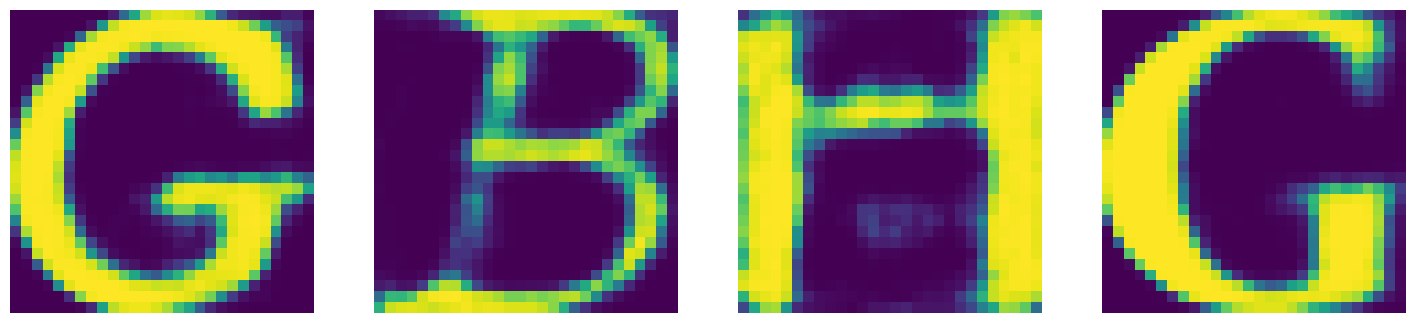

====> Epoch: 31 Average train loss: 104.8870
====> Test set loss: 105.4399


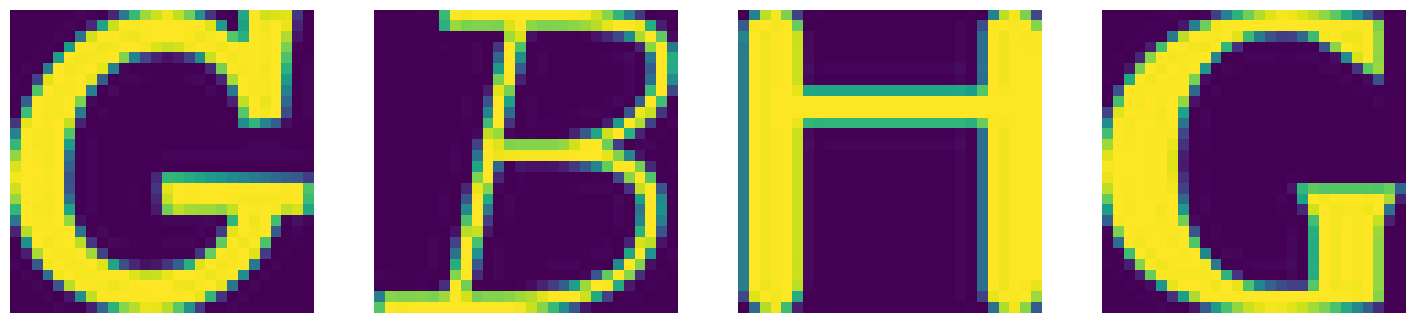

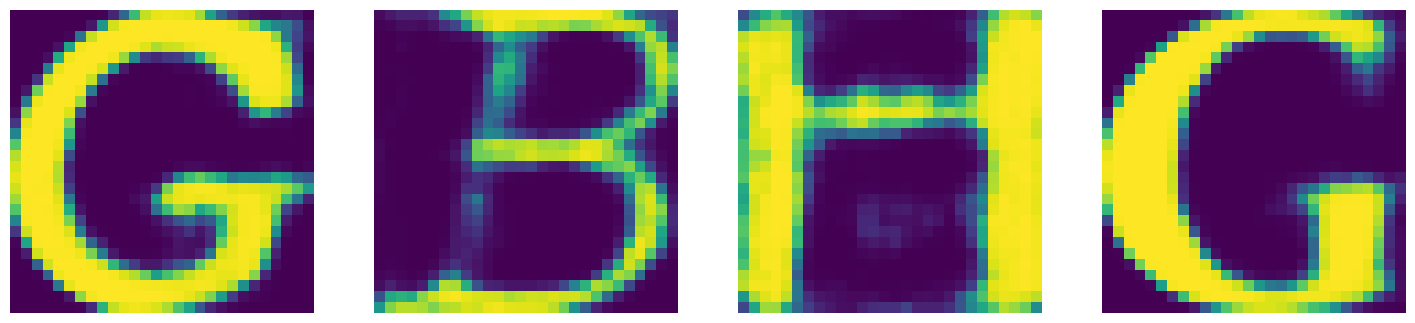

====> Epoch: 32 Average train loss: 104.6588
====> Test set loss: 106.4733


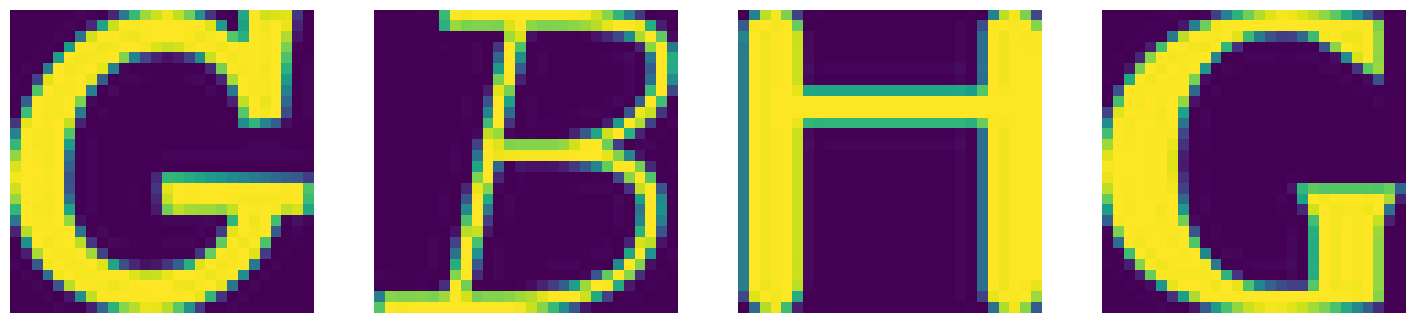

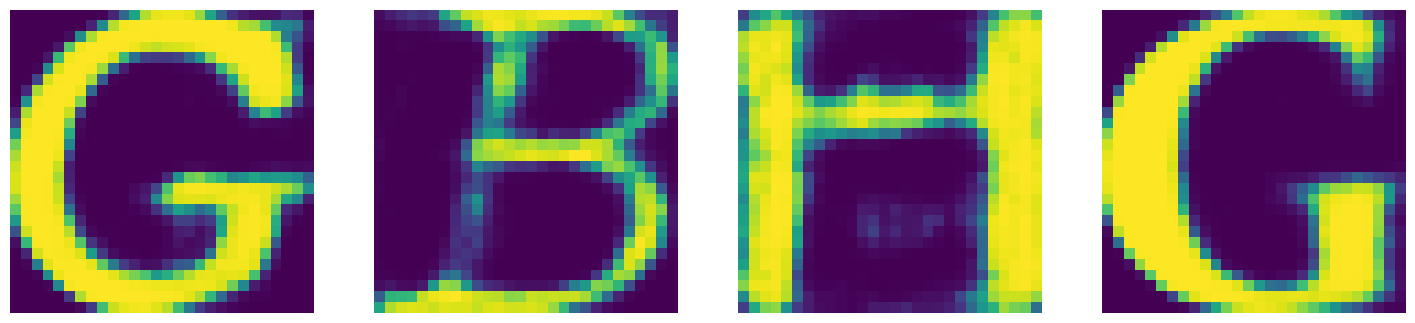

====> Epoch: 33 Average train loss: 104.3430
====> Test set loss: 105.6600


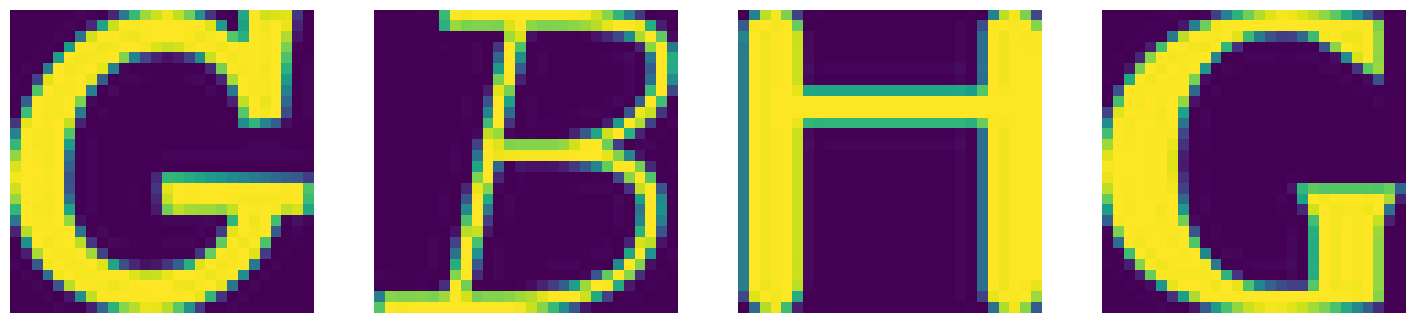

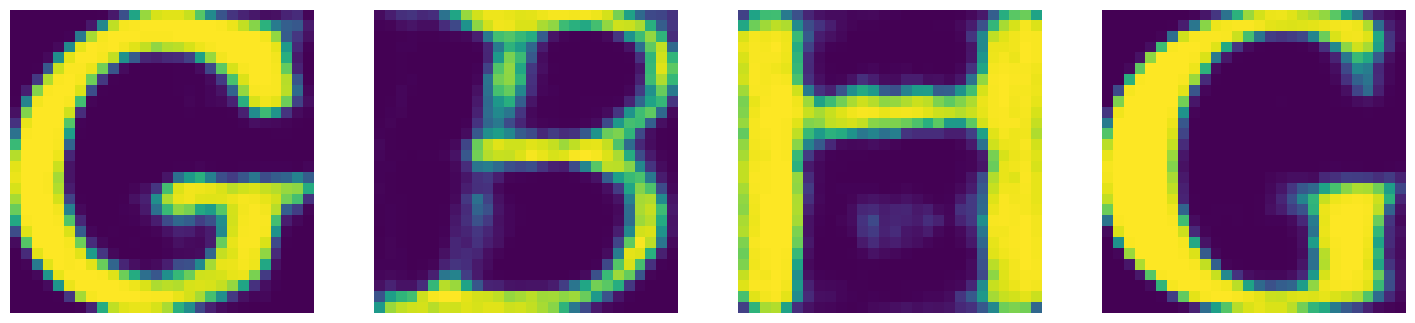

====> Epoch: 34 Average train loss: 104.0792
====> Test set loss: 105.8354


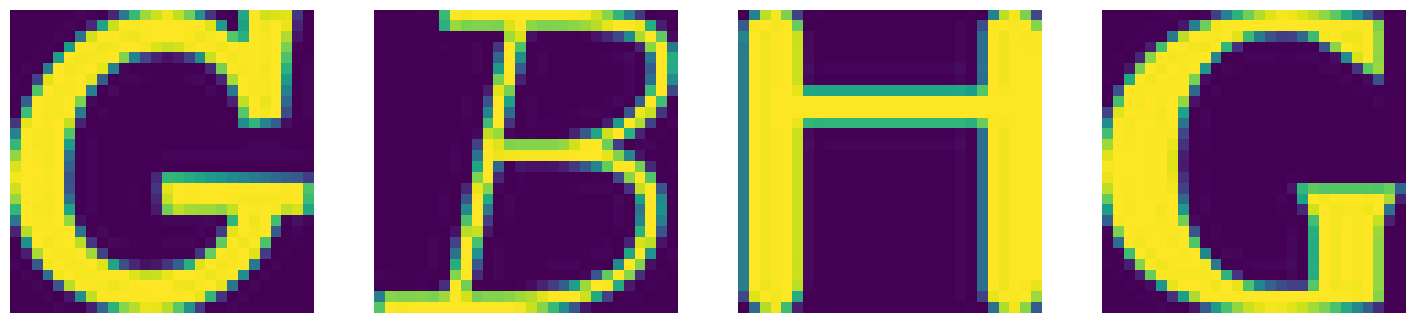

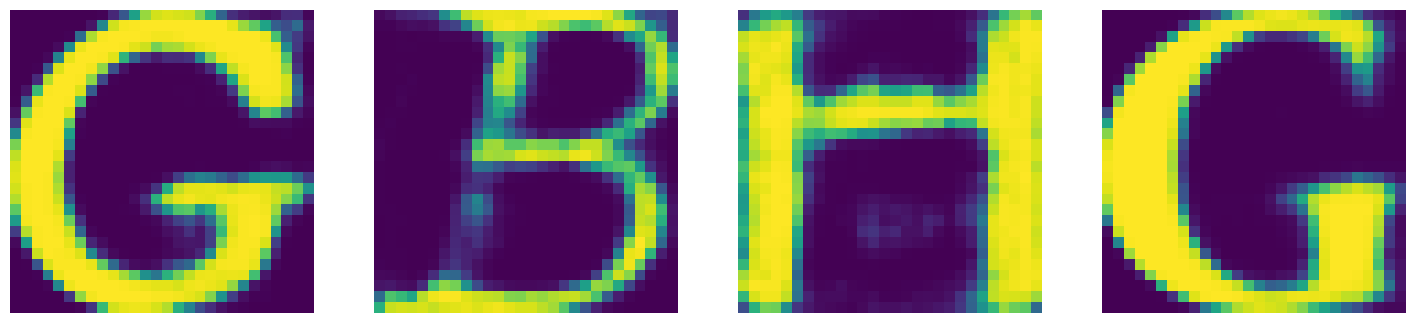

====> Epoch: 35 Average train loss: 103.7901
====> Test set loss: 105.1296


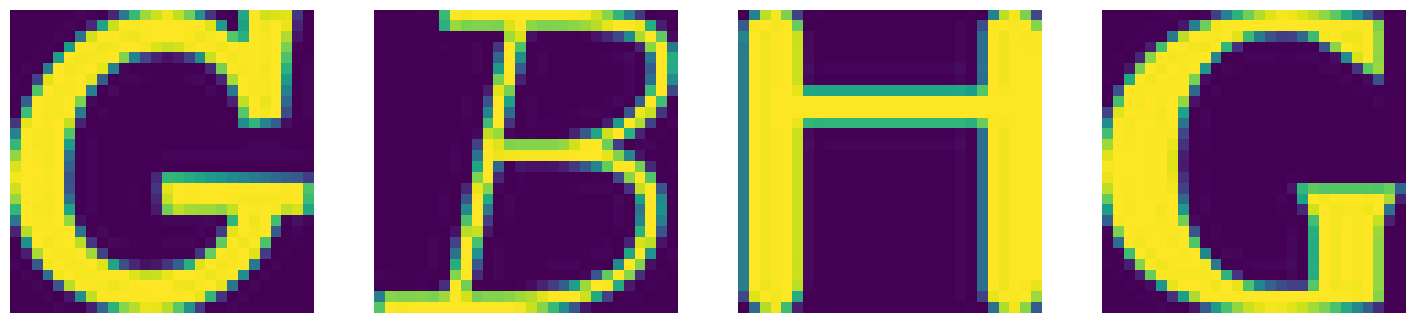

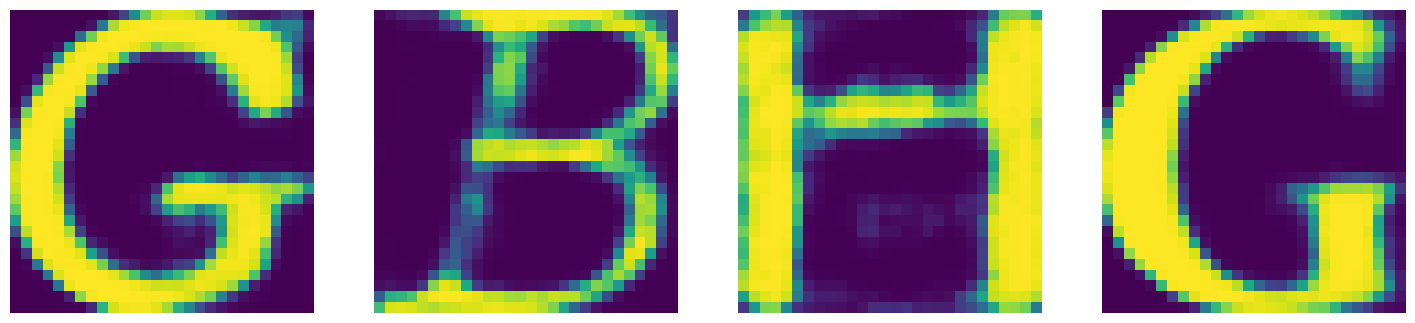

====> Epoch: 36 Average train loss: 103.5976
====> Test set loss: 105.6516


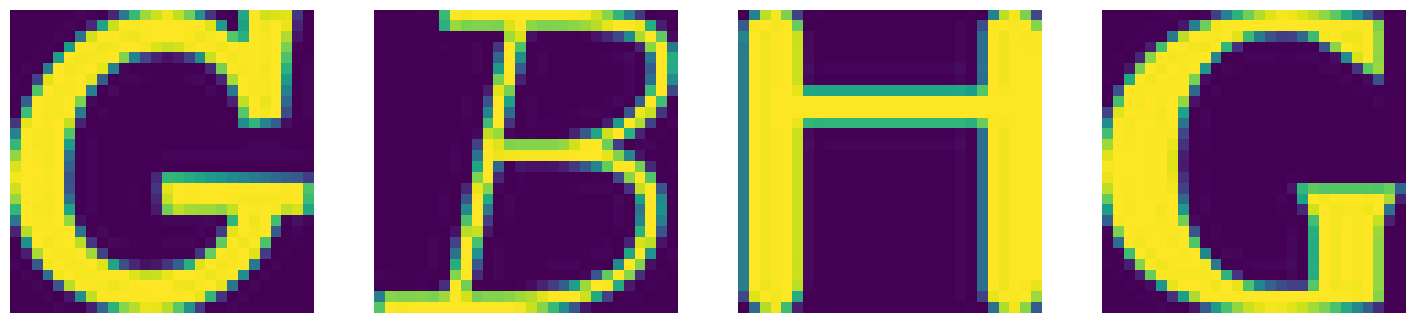

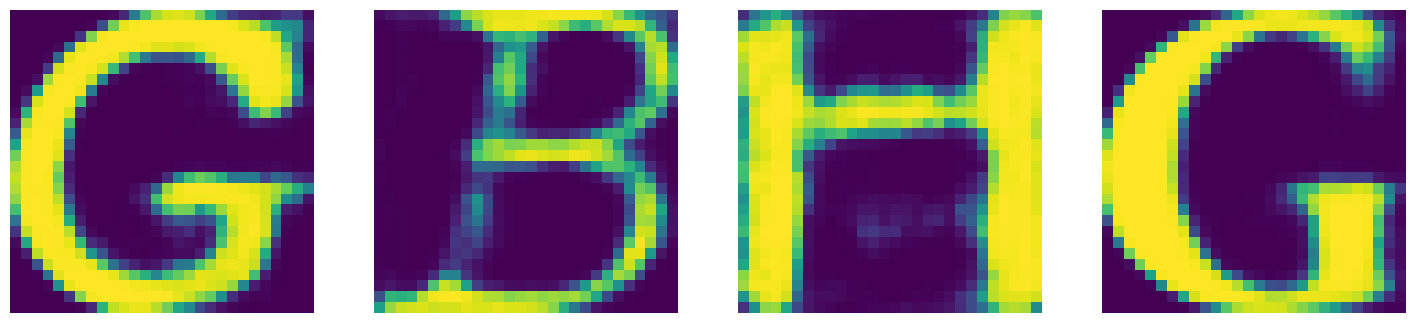

====> Epoch: 37 Average train loss: 103.2018
====> Test set loss: 105.1964


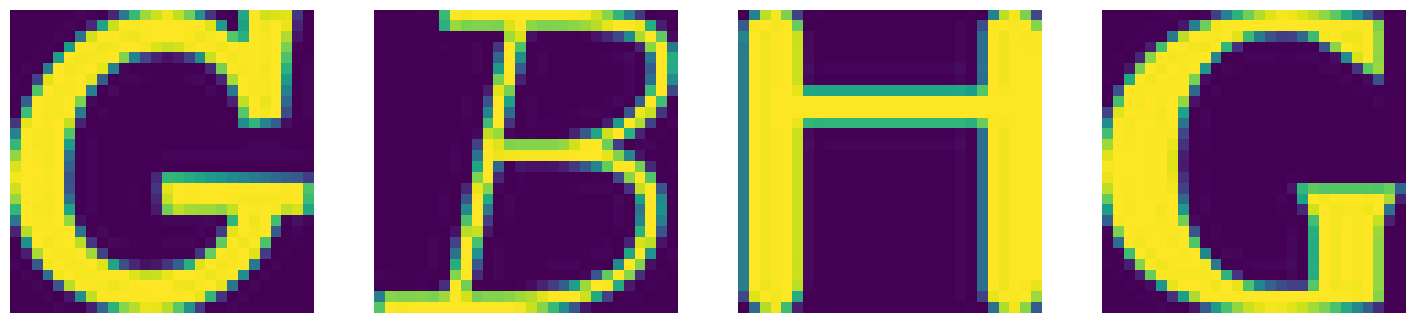

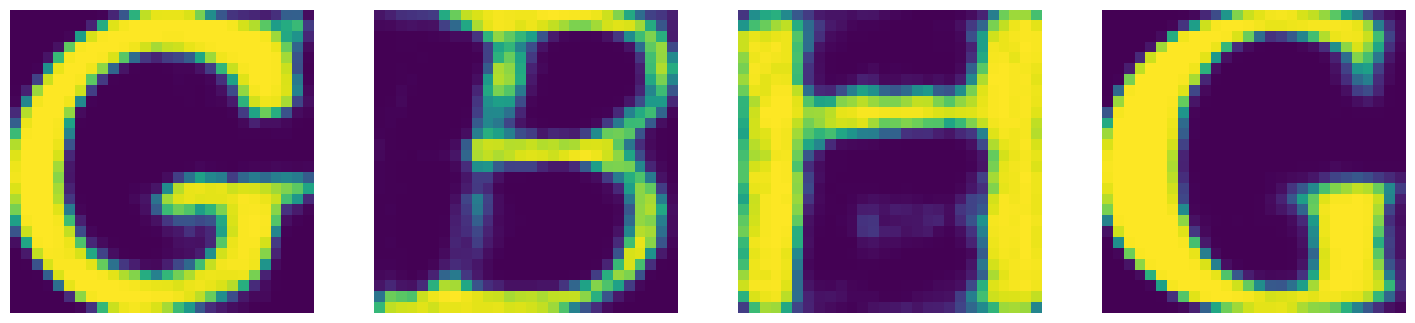

====> Epoch: 38 Average train loss: 102.9464
====> Test set loss: 105.8424


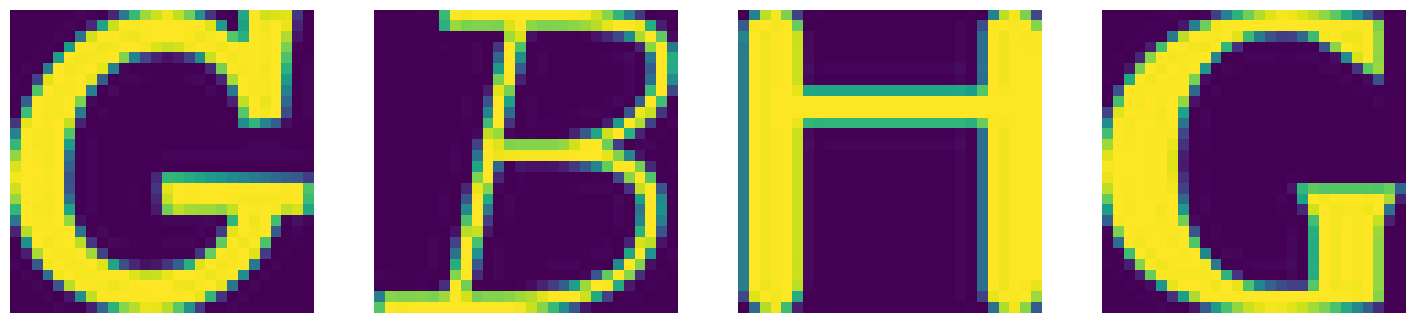

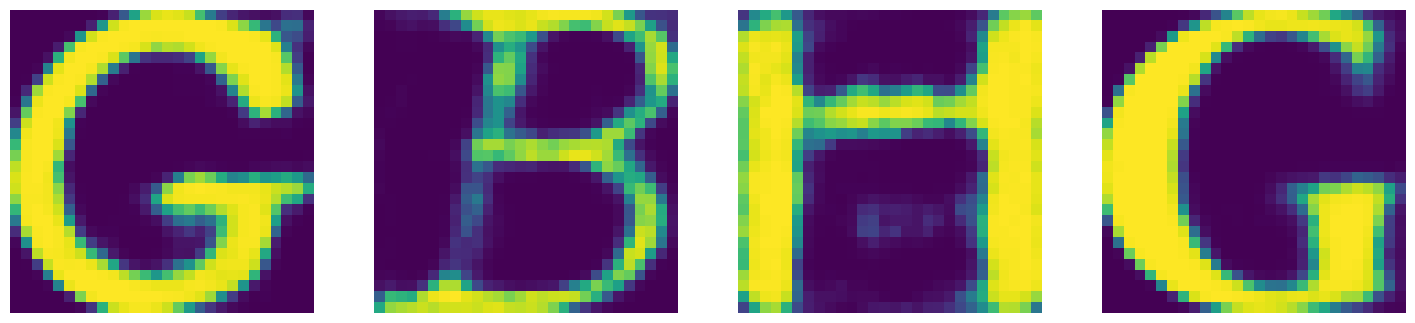

====> Epoch: 39 Average train loss: 102.8670
====> Test set loss: 104.4046


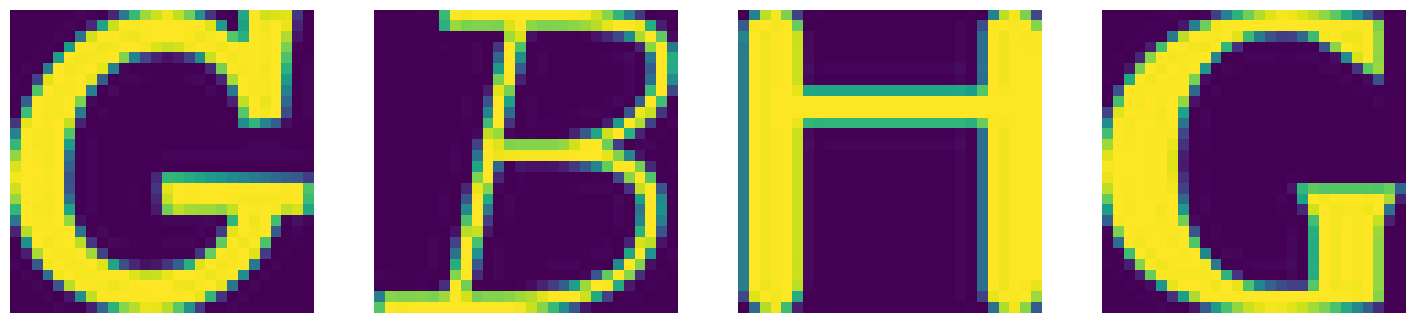

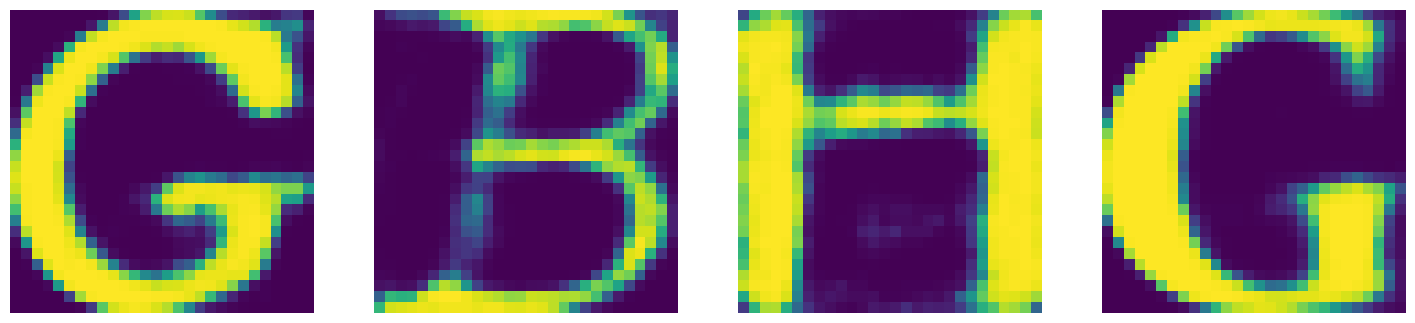

====> Epoch: 40 Average train loss: 102.5531
====> Test set loss: 104.5613


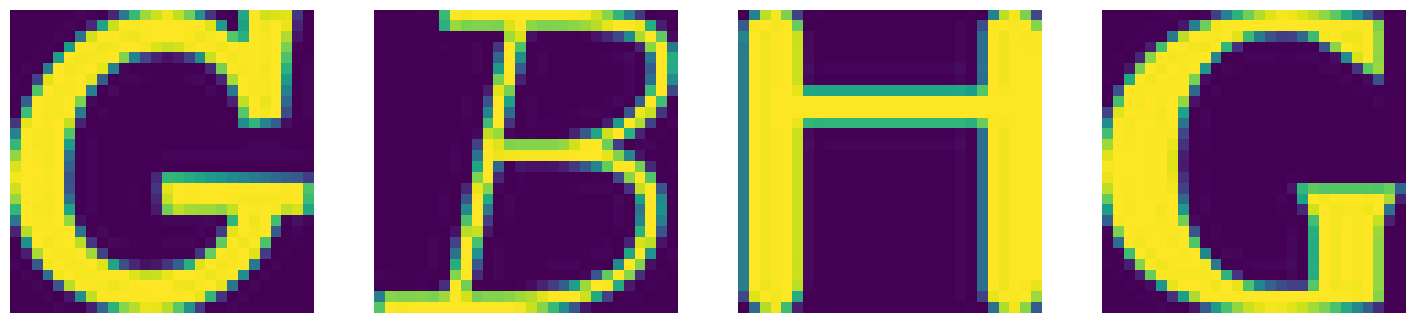

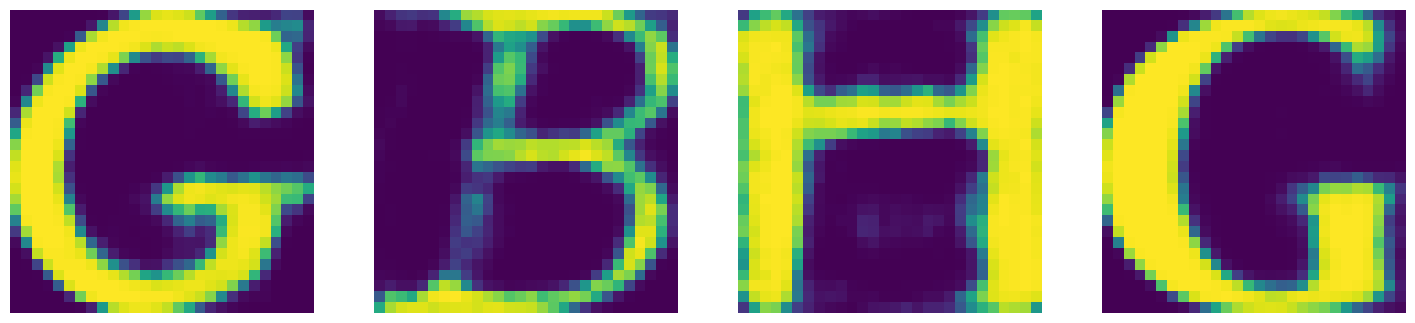

====> Epoch: 41 Average train loss: 102.2748
====> Test set loss: 105.4031


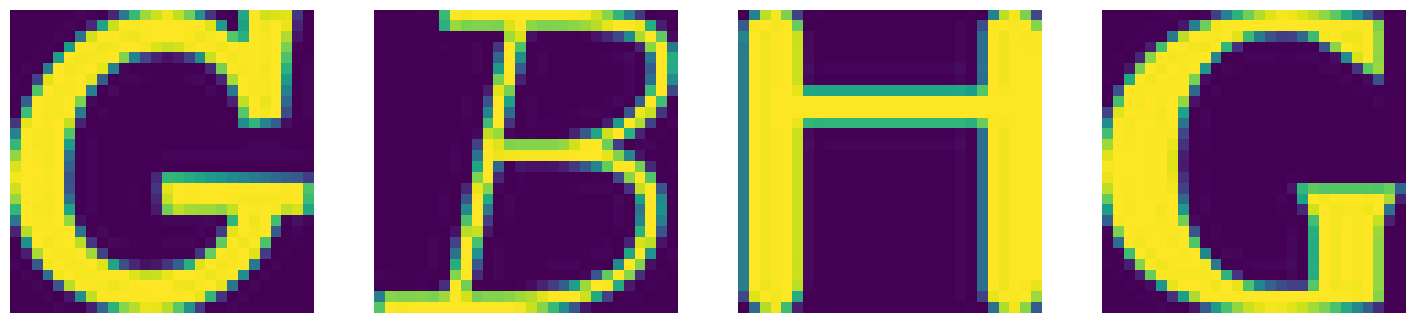

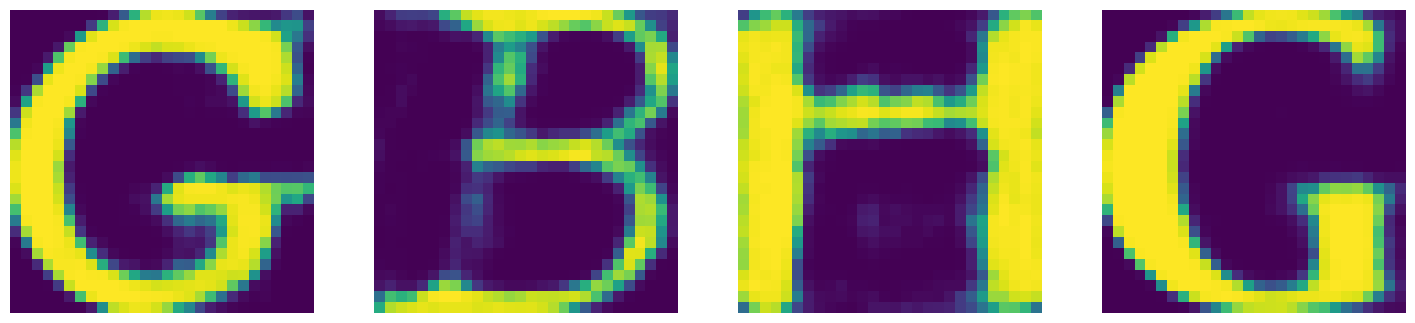

====> Epoch: 42 Average train loss: 102.0563
====> Test set loss: 105.3224


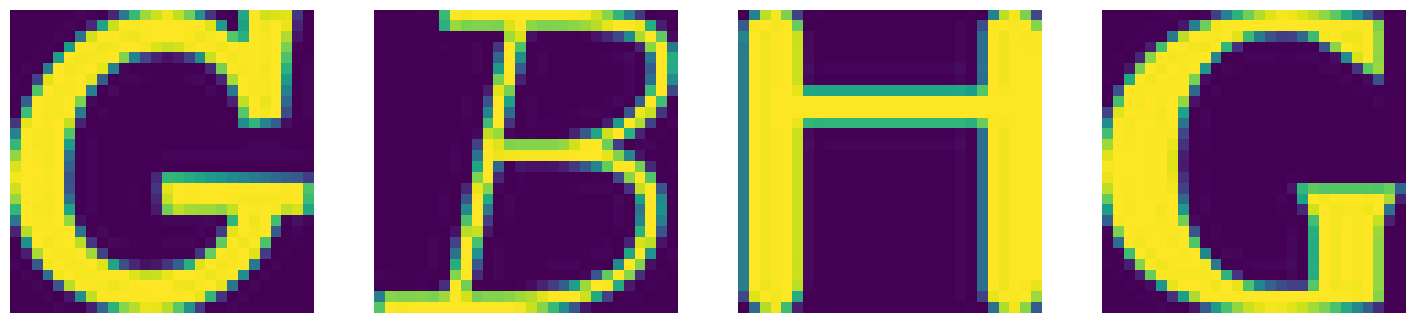

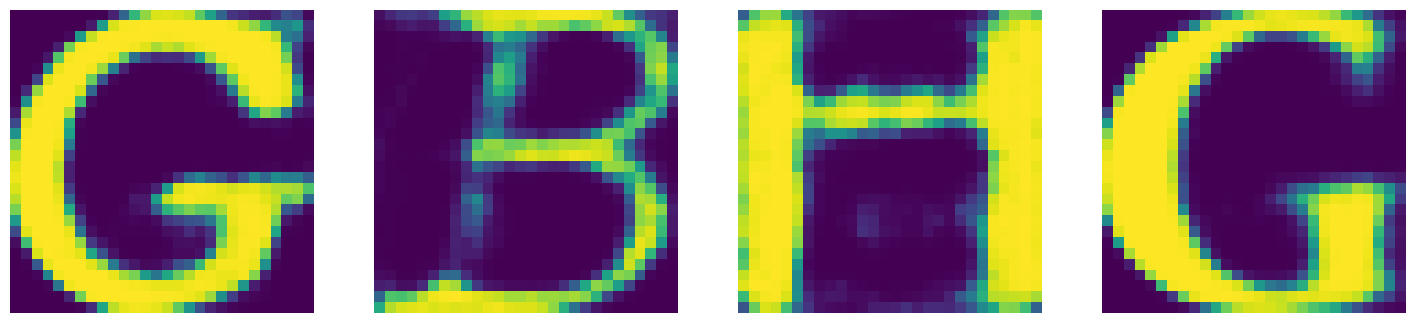

====> Epoch: 43 Average train loss: 101.7653
====> Test set loss: 105.0277


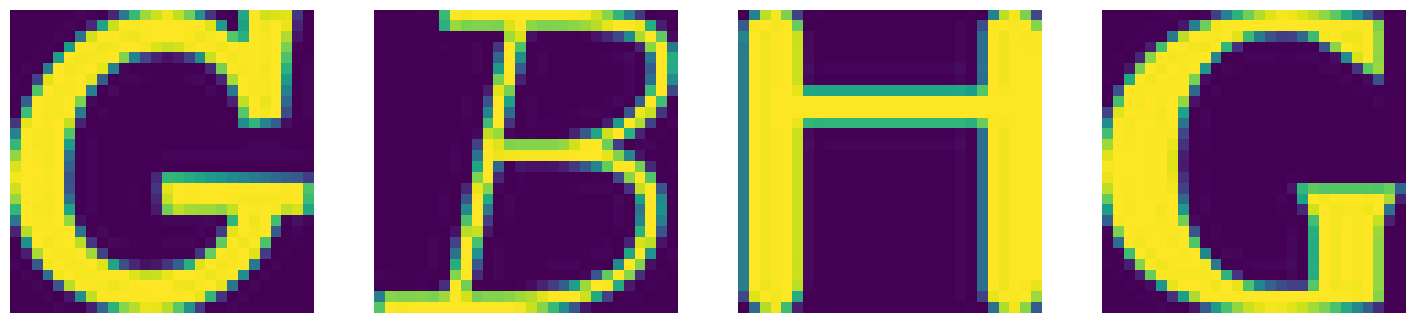

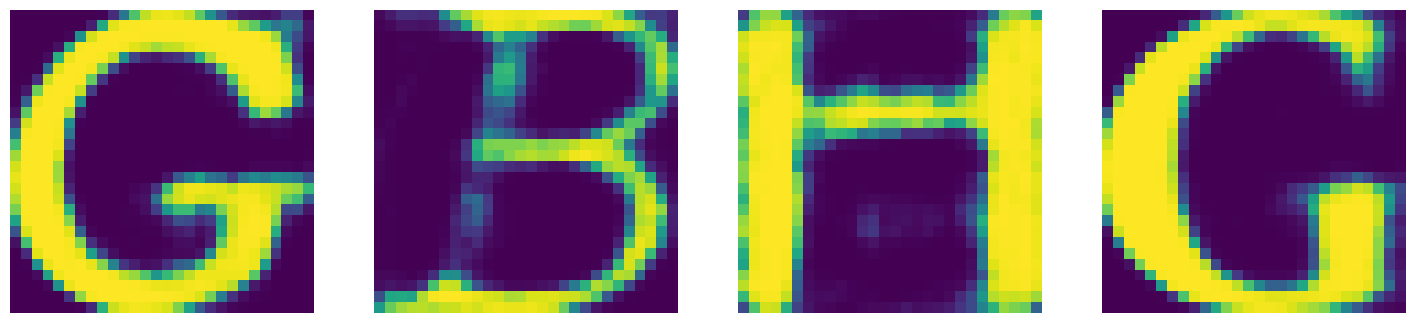

====> Epoch: 44 Average train loss: 101.5871
====> Test set loss: 103.4869


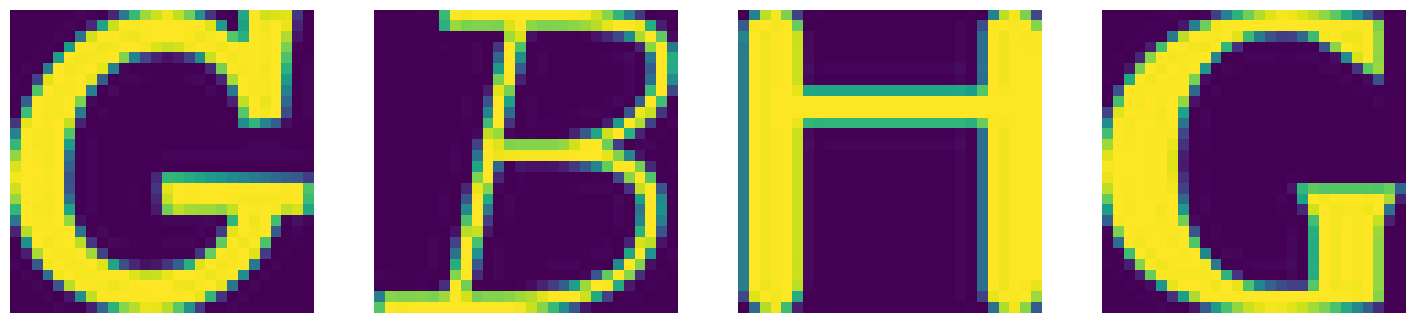

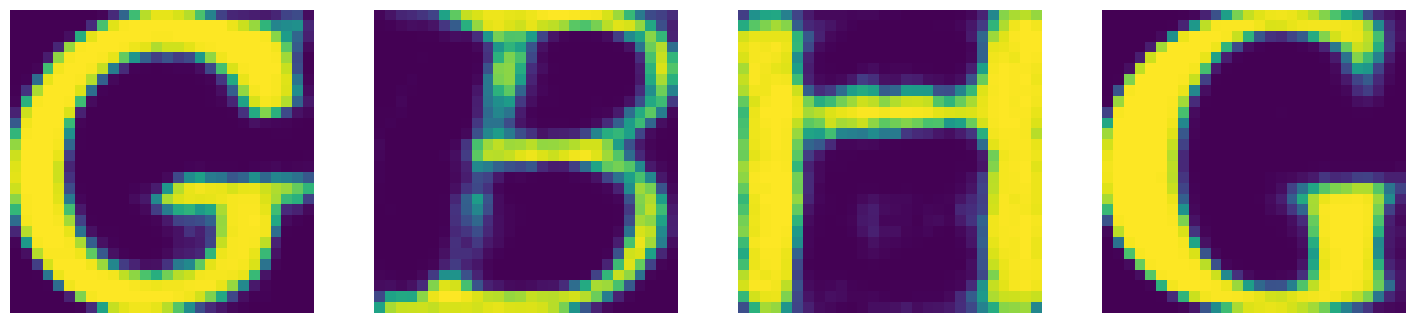

====> Epoch: 45 Average train loss: 101.4714
====> Test set loss: 104.3899


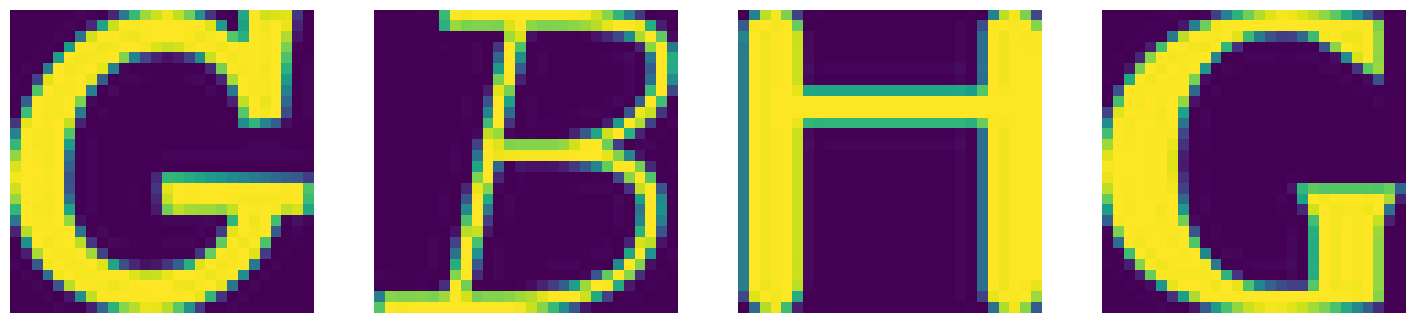

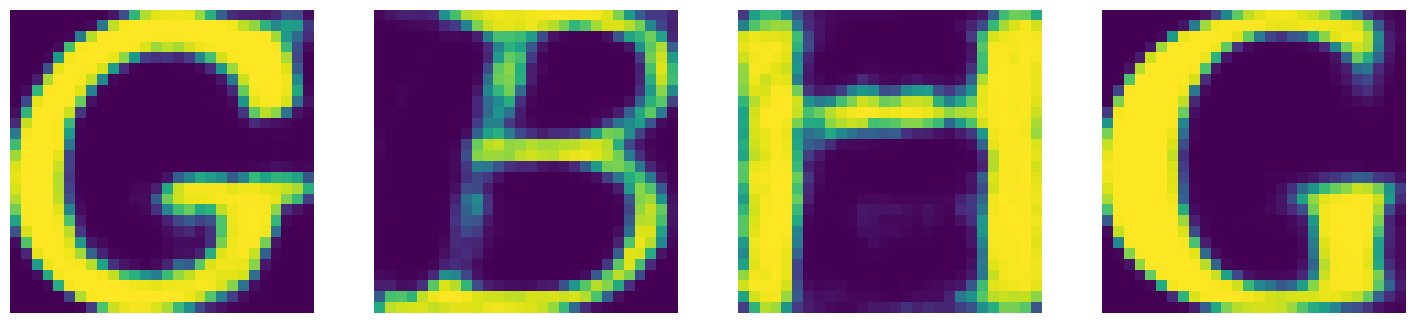

====> Epoch: 46 Average train loss: 101.3501
====> Test set loss: 104.8141


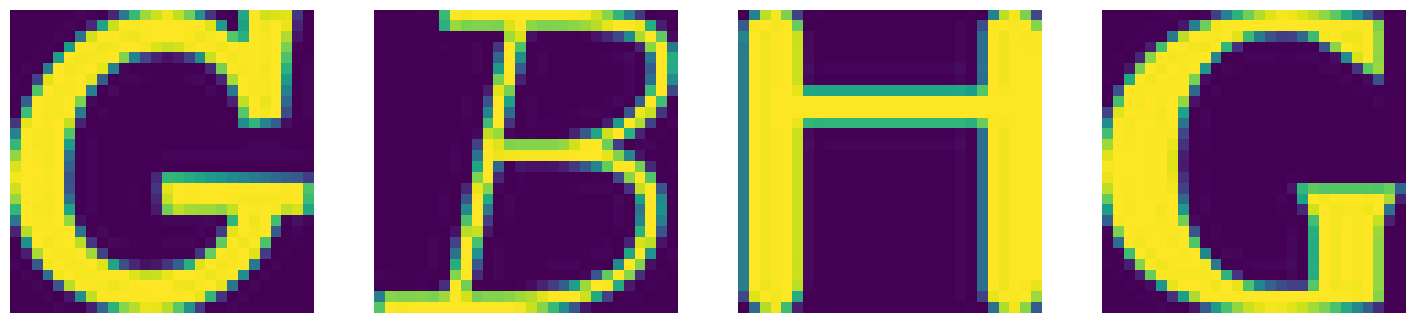

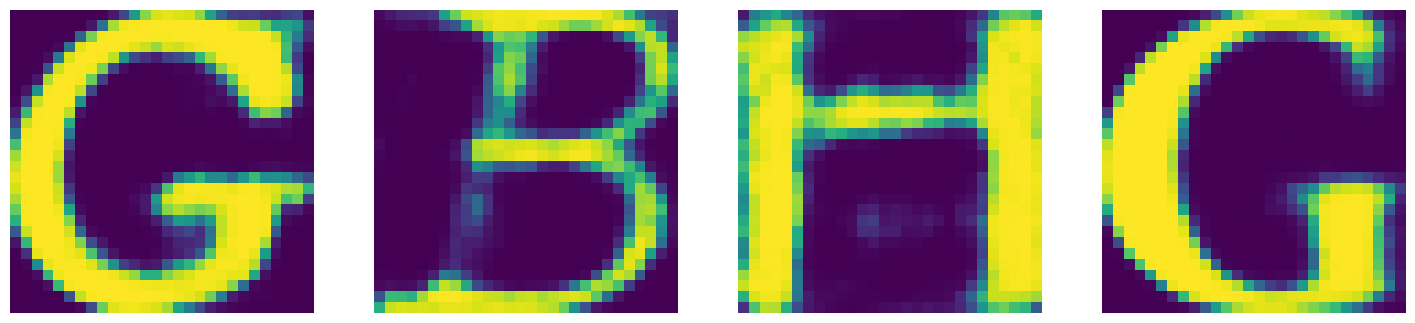

====> Epoch: 47 Average train loss: 101.1422
====> Test set loss: 104.7808


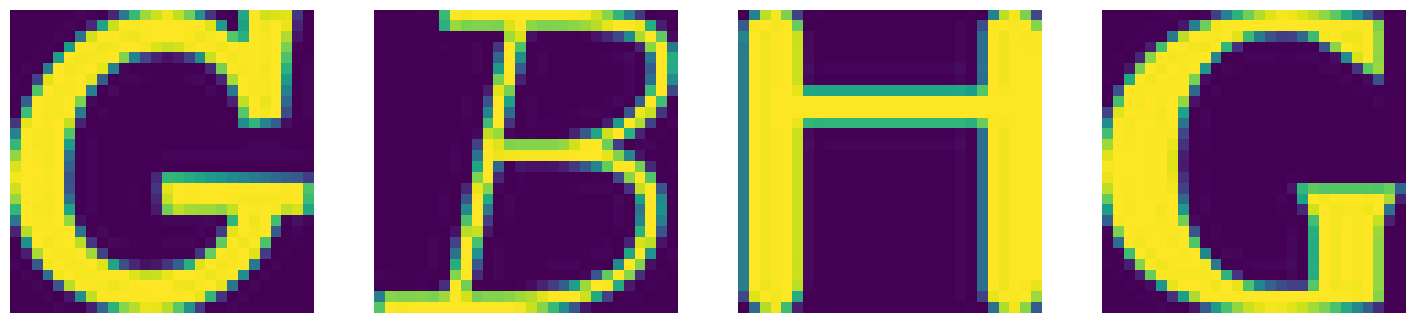

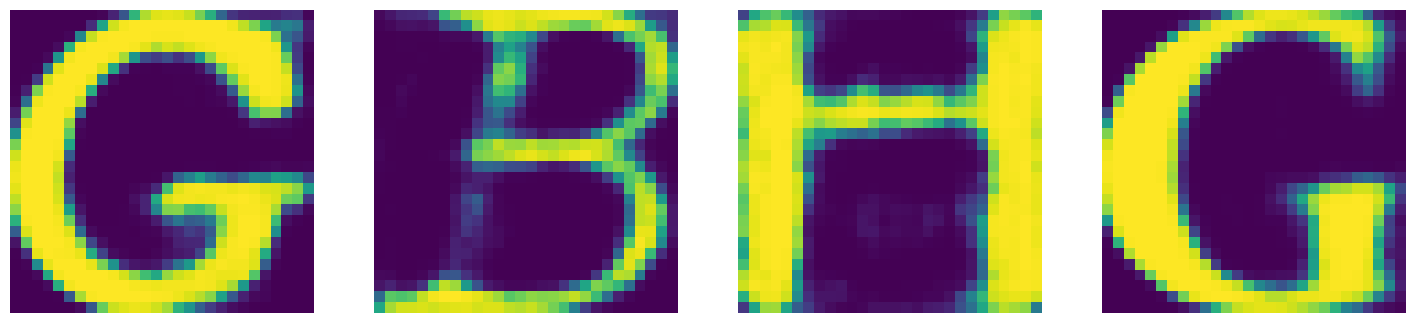

====> Epoch: 48 Average train loss: 100.8870
====> Test set loss: 104.9732


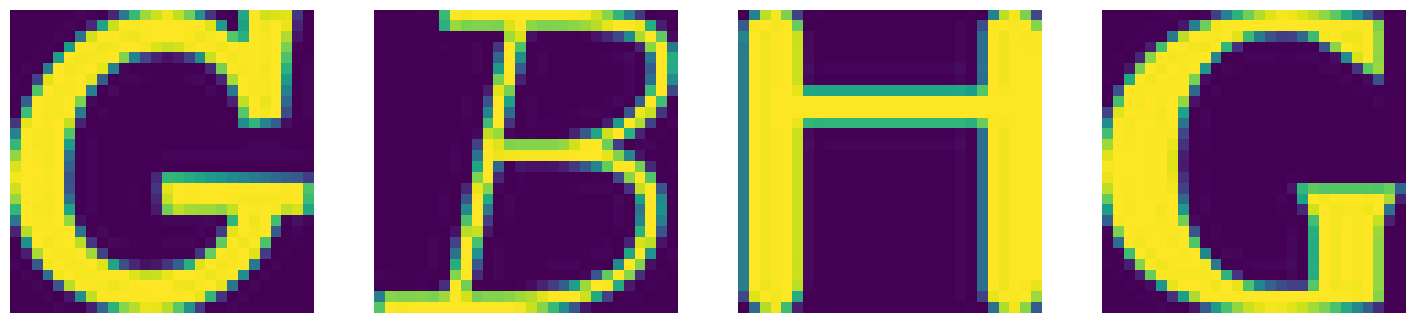

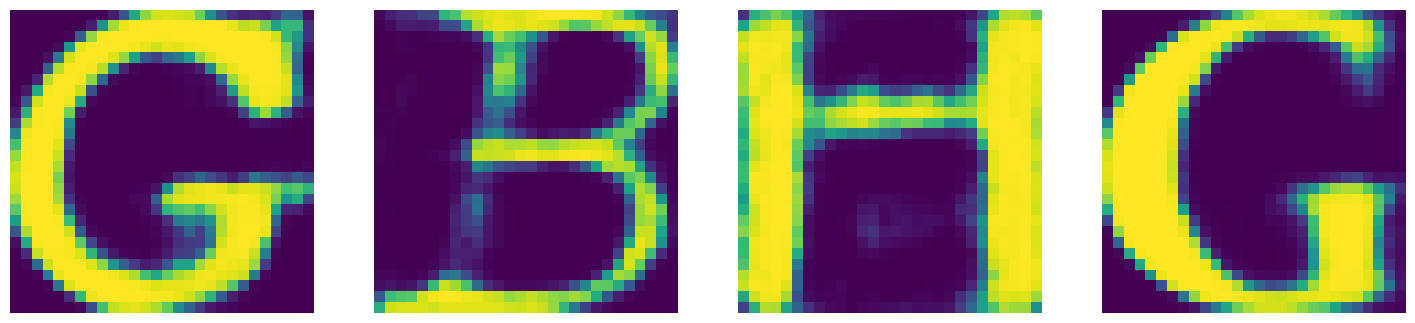

====> Epoch: 49 Average train loss: 100.8008
====> Test set loss: 105.1623


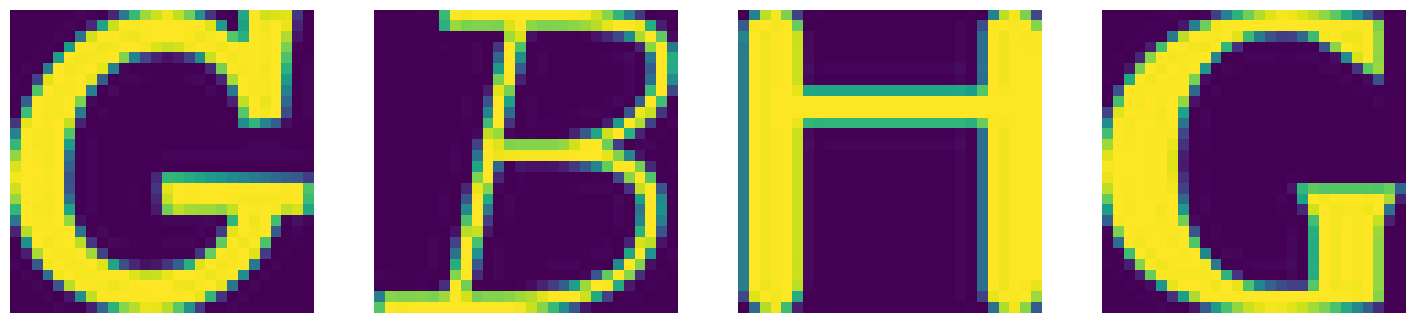

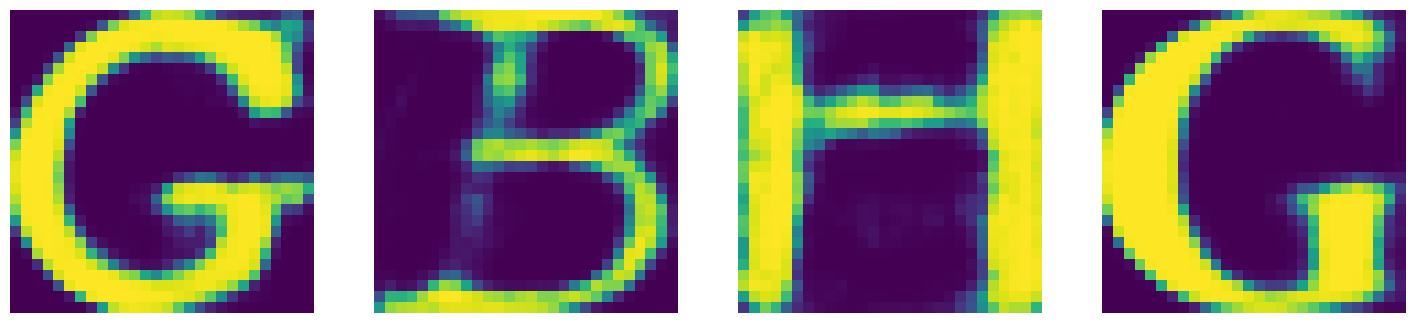

====> Epoch: 50 Average train loss: 100.7062
====> Test set loss: 104.3252


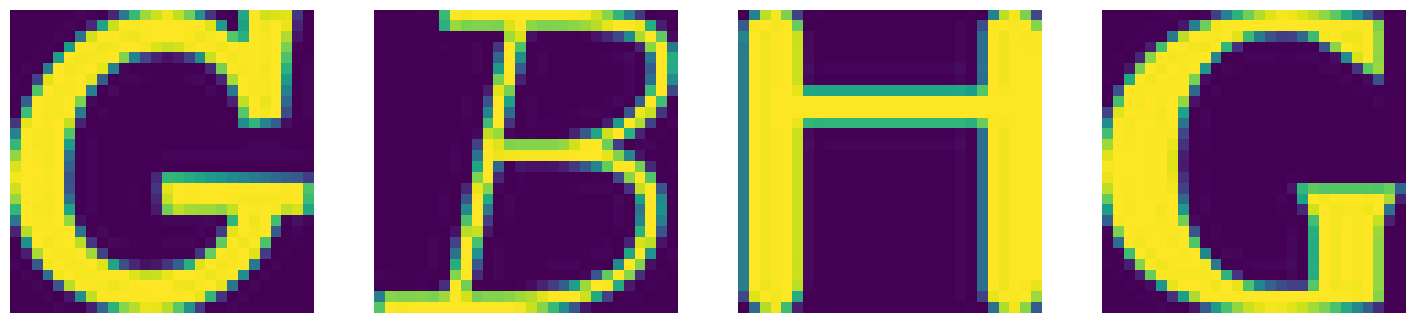

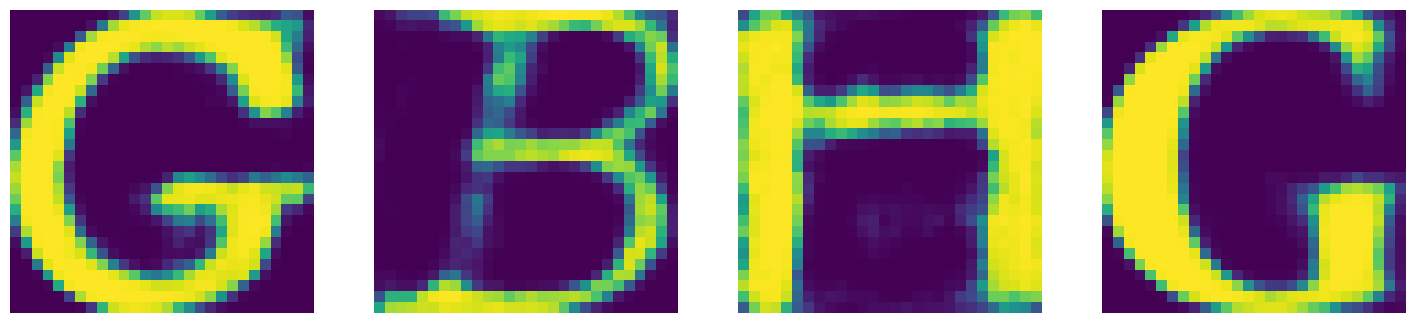

In [ ]:
latent_dim = 20
model = VAE(latent_dim).to(device)

# Setting the optimiser
learning_rate = 5e-4
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
)

epochs = 50
codes = dict(mu=list(), logσ2=list(), y=list())
train_losses_vae = []
test_losses_vae = []

for epoch in range(0, epochs + 1):
    # Training
    if epoch > 0:  # test untrained net first
        model.train()
        train_loss = 0
        for x, _ in train_loader:
            x = x.to(device)
            # ===================forward=====================
            x_hat, mu, logvar = model(x)
            loss = loss_function(x_hat, x, mu, logvar)
            train_loss += loss.item()
            # ===================backward====================
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        avg_train_loss = train_loss / len(train_loader.dataset)
        train_losses_vae.append(avg_train_loss)
        print(f'====> Epoch: {epoch} Average train loss: {avg_train_loss:.4f}')

    # Testing
    means, logvars, labels = list(), list(), list()
    with torch.no_grad():
        model.eval()
        test_loss = 0
        for x, y in test_loader:
            x = x.to(device)
            # ===================forward=====================
            x_hat, mu, logvar = model(x)
            test_loss += loss_function(x_hat, x, mu, logvar).item()
            # =====================log=======================
            means.append(mu.detach())
            logvars.append(logvar.detach())
            labels.append(y.detach())
    # ===================log========================
    codes['mu'].append(torch.cat(means))
    codes['logσ2'].append(torch.cat(logvars))
    codes['y'].append(torch.cat(labels))
    avg_test_loss = test_loss / len(test_loader.dataset)
    test_losses_vae.append(avg_test_loss)
    print(f'====> Test set loss: {avg_test_loss:.4f}')

    display_images(x, x_hat, 4)


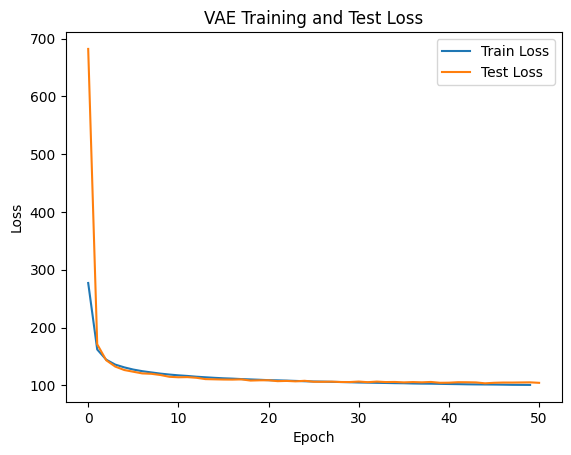

In [ ]:
plt.plot(train_losses_vae, label='Train Loss')
plt.plot(test_losses_vae, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training and Test Loss')
plt.legend()
plt.show()


### Generating New Images from the VAE

Once the VAE is trained, we can sample new points from the **latent space** to generate fresh images that the model has never seen before.

By drawing random latent vectors `z ~ N(0, I)` and passing them through the **decoder**, the model produces new, synthetic notMNIST-like characters.

Below, we display `N = 6` randomly generated samples to visualize how well the VAE has learned the underlying data distribution.


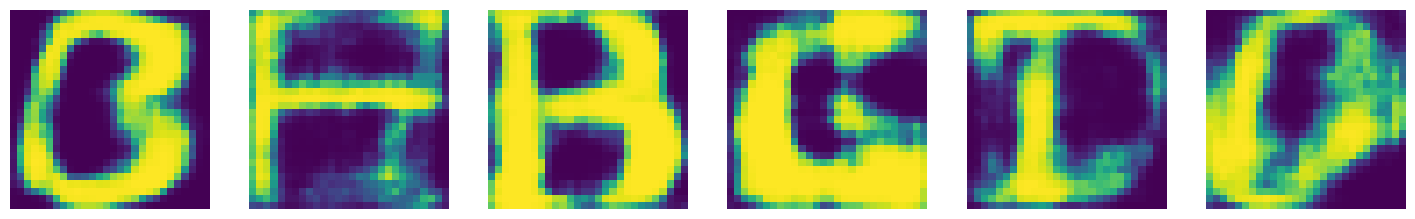

In [ ]:
N=6
display_images(None, model.generate(N), N)

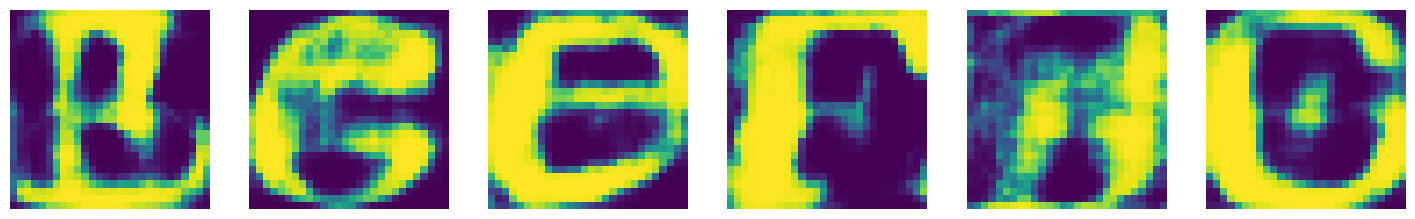

In [ ]:
N=6
display_images(None, model.generate(N), N)

### Visualizing Reconstructions from Latent Representations

To understand what the VAE has learned, we pick two test samples from the notMNIST dataset and explore how the model represents them in its **latent space**.

1. **Select Two Letters:**  
   Two images (e.g., `C` and `F`) are taken from the test set.

2. **Encode → Decode:**  
   Each image is encoded into its latent mean (`μ`) and then decoded back into an image using the VAE’s decoder.  
   This helps visualize how the model internally represents each letter in the latent space.

3. **Compare:**  
   We display:
   - The **original input letters**, and  
   - Their corresponding **decoded reconstructions** produced by the model.  

If the model has learned a meaningful latent representation, the decoded letters should resemble their inputs, showing that the VAE understands the overall structure of notMNIST characters rather than just memorizing pixels.


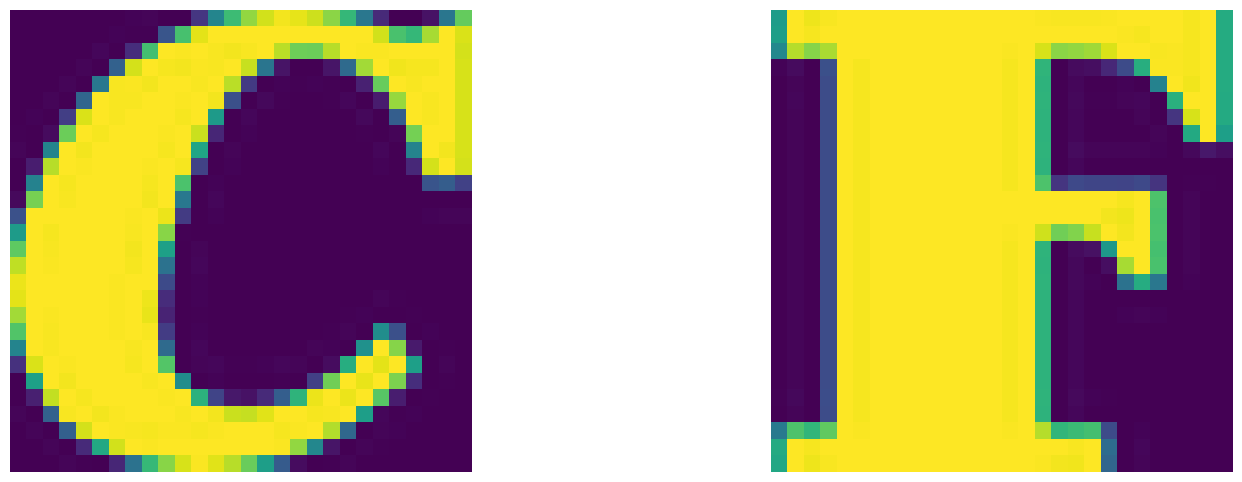

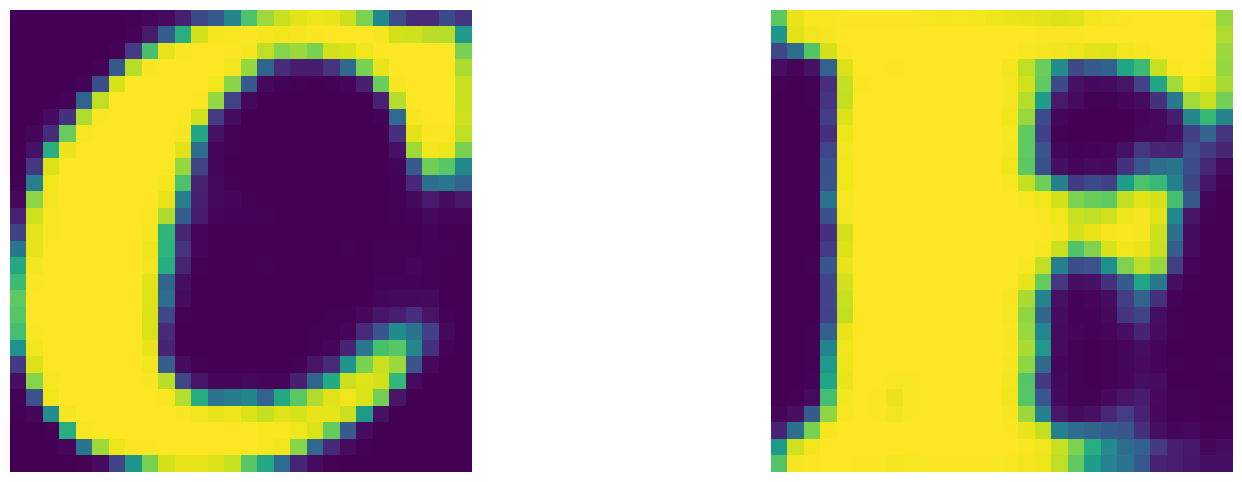

In [ ]:
x, _ = next(iter(test_loader))
x = x.to(device)
x_hat, mu, logvar = model(x)
A, B = 1, 14
sample = model.decoder(torch.stack((mu[A].data, mu[B].data), 0))
#sample = torch.stack((x_hat[A].data, x_hat[B].data), 0)
display_images(None, torch.stack(((
    x[A].data.view(-1),
    x[B].data.view(-1)
)), 0), 2)
display_images(None, torch.stack(((
    sample.data[0],
    sample.data[1]
)), 0), 2)


### Latent Space Interpolation

This section visualizes **smooth transitions** between two encoded samples (A → B) in the latent space.  
By linearly interpolating their latent vectors `mu[A]` and `mu[B]`, we generate intermediate latent codes and decode them back into images.  

This helps us observe how the **VAE’s latent space captures semantic continuity** — the images gradually morph from one letter to another, demonstrating the model’s ability to learn smooth latent representations.


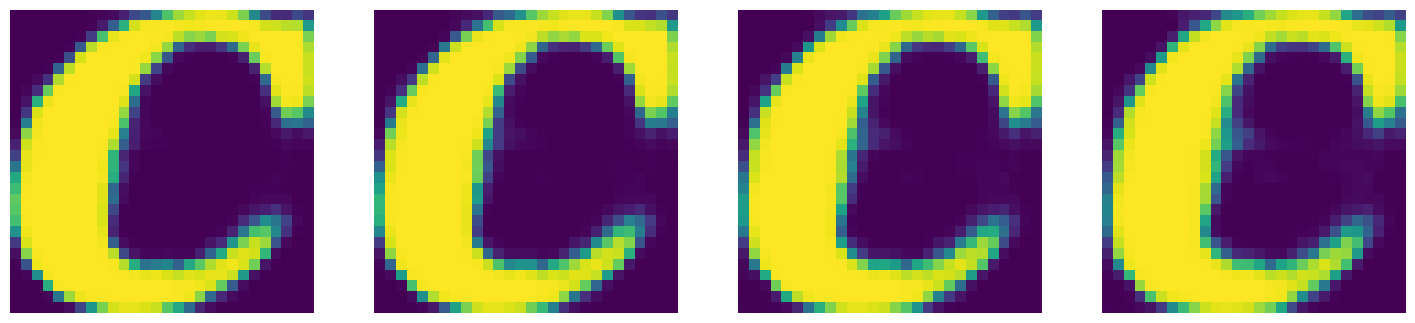

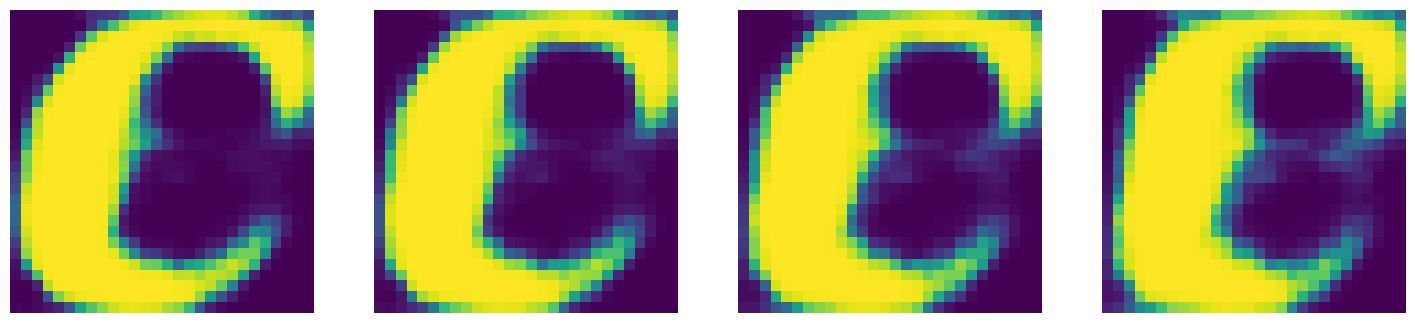

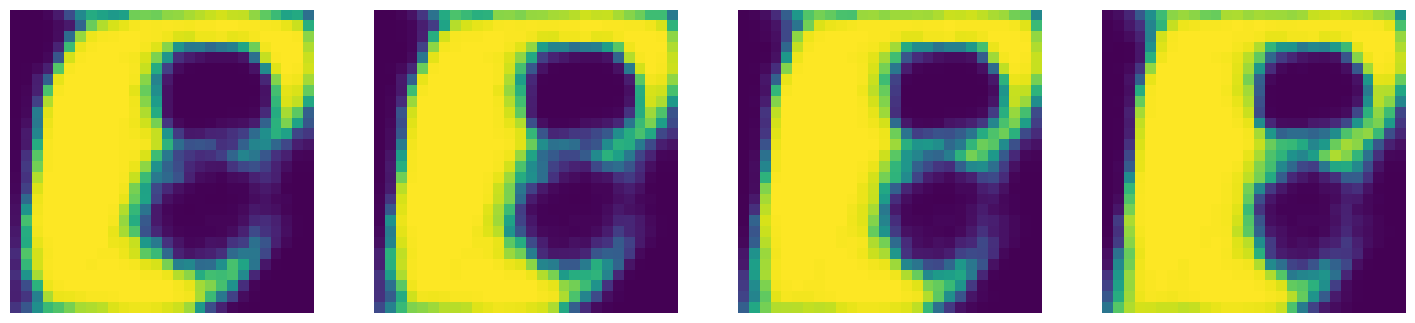

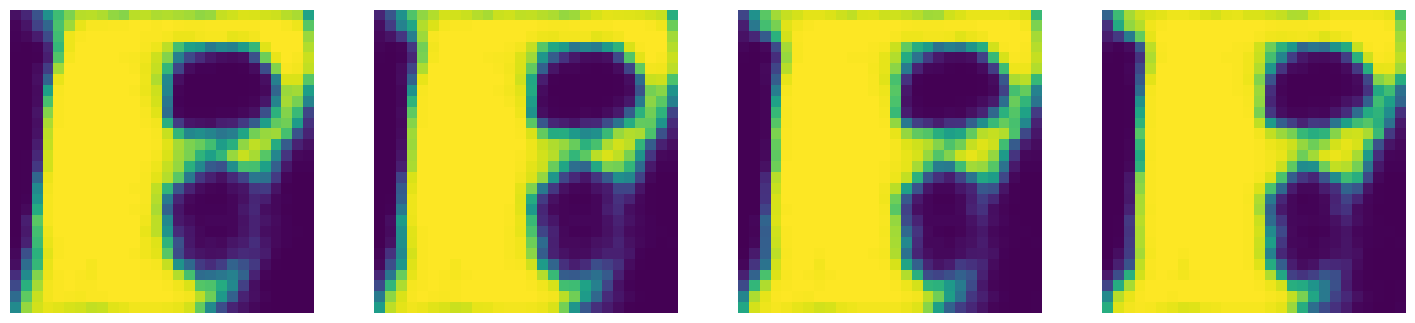

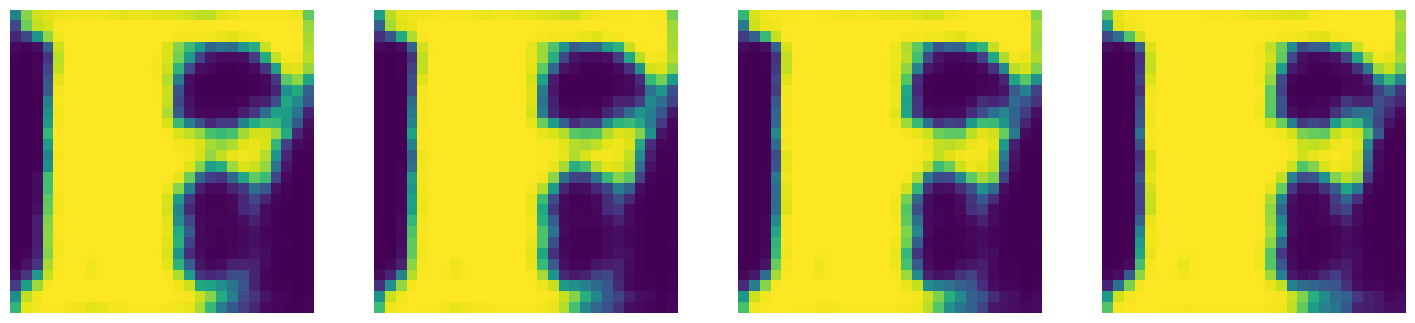

In [ ]:
# Perform an interpolation between input A and B, in N steps
N = 20
code = torch.Tensor(N, latent_dim).to(device)
sample = torch.Tensor(N, 28, 28).to(device)
for i in range(N):
    code[i] = i / (N - 1) * mu[B].data + (1 - i / (N - 1) ) * mu[A].data
    # sample[i] = i / (N - 1) * x[B].data + (1 - i / (N - 1) ) * x[A].data
img_set = model.decoder(code)
for i in range(N//4):
    display_images(None, img_set[i*4:4*(i+1)], 4)

------

### Conditional GAN

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Loading a Batch of Data

We load a single batch from the training DataLoader to inspect the images and their corresponding labels.  

- `imgs` contains a batch of images.  
- `labels` contains the corresponding class labels for each image in the batch.  

We print the first 20 labels to see a sample and also check the **range of labels** in the batch to confirm they span the expected classes (0–9 for letters 'A'–'J').


In [ ]:
imgs, labels = next(iter(train_loader))
print("Batch labels sample:", labels[:20].tolist())
print("Label range -> min:", int(labels.min()), "max:", int(labels.max()))


Batch labels sample: [5, 9, 7, 3, 5, 8, 5, 4, 1, 4, 3, 9, 9, 6, 7, 1, 5, 7, 8, 1]
Label range -> min: 0 max: 9


### Defining Key Hyperparameters

Before building the Conditional GAN, we define the main hyperparameters:

- `num_classes = 10` → Number of classes in the dataset (letters 'A'–'J').  
- `latent_dim = 100` → Dimension of the random noise vector fed to the generator.  
- `img_size = 28` → Size of each image (28×28 pixels).  
- `channels = 1` → Number of image channels (1 for grayscale images).  

These values will guide the architecture of both the generator and the discriminator.


In [ ]:
num_classes = 10
latent_dim = 100
img_size = 28
channels = 1


### Conditional Generator

The **Conditional Generator** creates images based on a random noise vector (`z`) and a class label:

- **Input:** Concatenation of noise `z` and one-hot class label.  
- **Fully connected layer:** Expands the input to a high-dimensional feature map.  
- **Deconvolution layers:** Upsample the features to reconstruct a 28×28 image.  
- **Output:** `tanh` activation scales pixel values between -1 and 1.  
- **Dropout:** Helps prevent overfitting.  

This setup allows the generator to produce images of a **specific class** rather than random images.


In [ ]:
def deconv(in_channels, out_channels, kernel_size, stride=2, padding=1, batch_norm=True):
    layers = [nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)]
    if batch_norm:
        layers.append(nn.BatchNorm2d(out_channels))
    return nn.Sequential(*layers)


class ConditionalGenerator(nn.Module):
    def __init__(self, z_size=100, conv_dim=128, num_classes=10):
        super().__init__()
        self.z_size = z_size
        self.num_classes = num_classes

        # Input dimensions for conditional GAN
        input_dim = z_size + num_classes


        self.fc = nn.Linear(input_dim, conv_dim * 4 * 7 * 7)

        # Deconvolution layers
        self.deconv1 = deconv(conv_dim * 4, conv_dim * 2, 4, 2, 1)
        self.deconv2 = deconv(conv_dim * 2, conv_dim, 4, 2, 1)
        self.deconv3 = nn.Conv2d(conv_dim, 1, 3, stride=1, padding=1)

        self.dropout = nn.Dropout(0.3)

    def forward(self, z, labels):
        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
        # Important for conditional generator one hot encoding of class labels+noise
        x = torch.cat([z, one_hot], dim=1)

        x = self.fc(x)
        x = self.dropout(x)
        x = x.view(-1, 512, 7, 7)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = torch.tanh(self.deconv3(x))
        return x

### Conditional Discriminator

The **Conditional Discriminator** determines whether an image is real or generated, **given its class label**.

- **Input:** Image `x` and one-hot class label.  
- **Label handling:** Labels are expanded to match the image dimensions and concatenated as extra channels.  
- **Convolution layers:** Extract features from the combined image+label input. Leaky ReLU activations and dropout stabilize training.  
- **Output:** Flattened features pass through a fully connected layer to produce a single real/fake score.  

This design allows the discriminator to judge if the image **matches the given class**, making the GAN conditional.


In [ ]:
def conv(in_channels, out_channels, kernel_size, stride=2, padding=1, batch_norm=True):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)]
    if batch_norm:
        layers.append(nn.BatchNorm2d(out_channels))
    return nn.Sequential(*layers)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, conv_dim=64, num_classes=10):
        super().__init__()
        self.num_classes = num_classes

        # Label channel concatenation handled dynamically
        self.conv1 = conv(1 + num_classes, conv_dim, 4, 2, 1, batch_norm=False)
        self.conv2 = conv(conv_dim, conv_dim * 2, 4, 2, 1)
        self.conv3 = conv(conv_dim * 2, conv_dim * 4, 3, 2, 1)
        self.dropout = nn.Dropout(0.5)


        self.fc = None

    def forward(self, x, labels):
        # expand label as channel map
        one_hot = F.one_hot(labels, num_classes=self.num_classes).float()
        one_hot = one_hot.view(-1, self.num_classes, 1, 1)
        one_hot = one_hot.repeat(1, 1, x.size(2), x.size(3))  # match x spatial size
        x = torch.cat([x, one_hot], dim=1)

        x = F.leaky_relu(self.conv1(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.conv2(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.conv3(x), 0.2)
        x = self.dropout(x)
        x = x.view(x.size(0), -1)

        if self.fc is None:
            self.fc = nn.Linear(x.size(1), 1).to(x.device)

        out = self.fc(x)
        return out


### Weight Initialization

We initialize the network weights to improve training stability:

- **Convolutional and linear layers:** Weights are drawn from a **normal distribution** with mean 0 and standard deviation 0.02.  
- **Biases:** Set to 0.  

Proper initialization helps the GAN train more reliably and prevents issues like vanishing or exploding gradients.


In [ ]:
#Initializing the weights to a normal distribution, centered around 0, with a standard deviation of 0.02.

def weights_init_normal(m):
    """
    :param m: A module or layer in a network
    """
    # like `Conv`, `BatchNorm2d`, `Linear`, etc.
    classname = m.__class__.__name__

    #  initial weights to convolutional and linear layers
    if (classname.find('Conv') != -1 or classname.find('Linear') != -1):
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    if hasattr(m, 'bias') and m.bias is not None:
        nn.init.constant_(m.bias.data, 0.0)

### Model Initialization

We create the **Conditional GAN models** with specified hyperparameters:

- `d_conv_dim = 64` → Base convolution dimension for the discriminator.  
- `g_conv_dim = 128` → Base convolution dimension for the generator.  
- `z_size = 100` → Size of the latent noise vector.  

**Steps:**

1. Instantiate the `ConditionalDiscriminator` and `ConditionalGenerator`.  
2. Apply the **normal weight initialization** to both models.  

This sets up the GAN for training with stable starting weights.


In [ ]:
# model hyperparameters
d_conv_dim = 64
g_conv_dim = 128
z_size = 100
# building discriminator and generator from the classes defined above
discriminator = ConditionalDiscriminator(d_conv_dim)
generator = ConditionalGenerator(z_size=z_size, conv_dim=g_conv_dim)

# initialize model weights
discriminator.apply(weights_init_normal)
generator.apply(weights_init_normal)
print("done")

done


In [ ]:
# let's look at our discriminator model
print(discriminator)

ConditionalDiscriminator(
  (conv1): Sequential(
    (0): Conv2d(11, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
# let's look at our generator model
print(generator)

ConditionalGenerator(
  (fc): Linear(in_features=110, out_features=25088, bias=True)
  (deconv1): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (deconv2): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (deconv3): Conv2d(128, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
use_gpu = torch.cuda.is_available()

### Optimizers

We use the **Adam optimizer** for both the generator and discriminator:

- **Learning rate:** `lr = 0.0002`  
- **Adam hyperparameters:** `beta1 = 0.5`, `beta2 = 0.999`  


- `discriminator_optimizer` → updates discriminator weights.  
- `generator_optimizer` → updates generator weights.


In [ ]:
lr = 0.0002 #learning rate
beta1=0.5

beta2=0.999

# optimizers for the conditional discriminator D and generator G
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr , (beta1, beta2)) # for discriminator
generator_optimizer = torch.optim.Adam(generator.parameters(), lr, (beta1, beta2)) # for generator

### Loss Functions

We use **Binary Cross-Entropy with logits** (`BCEWithLogitsLoss`) to train the GAN:

- **Real loss (`real_loss`)**: Measures how well the discriminator identifies real images.  
  - Optionally applies **label smoothing** by setting real labels to 0.9 instead of 1, which can improve training stability.  

- **Fake loss (`fake_loss`)**: Measures how well the discriminator identifies generated (fake) images as fake.  

These losses guide the discriminator to distinguish real vs. fake images and the generator to produce more realistic images.


In [ ]:
criterion = nn.BCEWithLogitsLoss()

def real_loss(D_out, smooth=False):
    batch_size = D_out.size(0)
    labels = torch.ones(batch_size, device=D_out.device)
    if smooth:
        labels = labels * 0.9
    return criterion(D_out.squeeze(), labels)

def fake_loss(D_out):
    batch_size = D_out.size(0)
    labels = torch.zeros(batch_size, device=D_out.device)
    return criterion(D_out.squeeze(), labels)


### Moving Models to Device

We set the computation device:

- `device = "cuda"` if a GPU is available, otherwise `"cpu"`.  
- Both the **generator** and **discriminator** are moved to this device to ensure all computations happen on the same hardware.  

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = generator.to(device)
discriminator = discriminator.to(device)


### Training Loop

The `train` function performs adversarial training of the Conditional GAN:

- **Discriminator:** Learns to distinguish real images from fake images conditioned on labels.  
- **Generator:** Learns to produce realistic images that match the given labels.  


In [ ]:
# Use 'device' defined earlier instead of train_on_gpu's logic
# We will assume train_on_gpu is a boolean flag to check if we use the 'cuda:0' device

def train(D, G, n_epochs, train_on_gpu, print_every=50):
    '''Trains adversarial networks for some number of epochs'''

    # Use the 'device' variable from setup
    D.to(device)
    G.to(device)

    # keep track of loss and generated, "fake" samples
    samples = []
    losses = []

    # Get some fixed data for sampling.
    sample_size=16
    fixed_z = np.random.uniform(-1, 1, size=(sample_size, z_size))
    fixed_z = torch.from_numpy(fixed_z).float().to(device)

    # ALSO NEED FIXED LABELS for consistent sampling! (e.g., all 0s, 1s, etc.)
    # We will generate a fixed sequence of labels 0, 1, 2, ...
    fixed_labels = torch.arange(0, num_classes).repeat(sample_size // num_classes + 1)[:sample_size].to(device)


    # epoch training loop
    for epoch in range(n_epochs):

        # batch training loop
        # Data loader now returns (real_images, real_labels)
        for batch_i, (real_images, real_labels) in enumerate(train_loader):

            batch_size = real_images.size(0)

            # --- Device and Data Prep ---
            real_images = real_images.to(device)
            real_labels = real_labels.to(device) # CRITICAL: Move labels to device
            # NOTE: Removed 'scale_images' call. Your dataloader already scales images to [-1, 1].

            # ============================================
            # 1. TRAIN THE DISCRIMINATOR
            # ============================================
            discriminator_optimizer.zero_grad()

            # 1A. Train with ALL REAL samples
            # CRITICAL: Pass real_labels to D
            D_real = D(real_images, real_labels)
            d_real_loss = real_loss(D_real)

            # 1B. Train with ALL FAKE samples

            # Generate random noise Z
            z = torch.randn(batch_size, z_size).to(device)
            # CRITICAL: Generate random FAKE LABELS for the Generator's output
            fake_labels = torch.randint(0, num_classes, (batch_size,)).to(device)

            # Generate fake images (Pass Z and FAKE LABELS)
            fake_images = G(z, fake_labels)

            # Calculate D loss on fake images (Pass FAKE images and FAKE LABELS)
            D_fake = D(fake_images.detach(), fake_labels) # detach G from D's update
            d_fake_loss = fake_loss(D_fake)

            # Total D loss
            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            discriminator_optimizer.step()

            # ============================================
            # 2. TRAIN THE GENERATOR
            # ============================================
            generator_optimizer.zero_grad()

            # Re-generate Z and FAKE LABELS (best practice to sample fresh)
            z = torch.randn(batch_size, z_size).to(device)
            fake_labels = torch.randint(0, num_classes, (batch_size,)).to(device)

            # Generate new fake images (Pass Z and FAKE LABELS)
            fake_images = G(z, fake_labels)

            # Calculate G loss (Pass FAKE images and FAKE LABELS)
            # G wants D to classify these as REAL, so we use real_loss
            D_fake = D(fake_images, fake_labels)
            g_loss = real_loss(D_fake)

            g_loss.backward()
            generator_optimizer.step()

            # Print some loss stats
            if batch_i % print_every == 0:
                # append discriminator loss and generator loss
                losses.append((d_loss.item(), g_loss.item()))
                # print discriminator and generator loss
                print('Epoch [{:5d}/{:5d}] | d_loss: {:6.4f} | g_loss: {:6.4f}'.format(
                        epoch+1, n_epochs, d_loss.item(), g_loss.item()))


        ## AFTER EACH EPOCH##
        # generate and save sample, fake images
        G.eval() # for generating samples
        # CRITICAL: Use fixed_labels to generate consistent samples
        samples_z = G(fixed_z, fixed_labels).cpu().data.numpy()
        samples.append(samples_z)
        G.train() # back to training mode

    # Save training generator samples
    with open('train_samples.pkl', 'wb') as f:
        pkl.dump(samples, f)

    # finally return losses
    return losses

In [ ]:
n_epochs = 20
losses = train(discriminator, generator, n_epochs=n_epochs, train_on_gpu = use_gpu)

Epoch [    1/   20] | d_loss: 1.4582 | g_loss: 0.8518
Epoch [    1/   20] | d_loss: 1.4350 | g_loss: 0.9313
Epoch [    1/   20] | d_loss: 1.4292 | g_loss: 0.8527
Epoch [    1/   20] | d_loss: 1.2946 | g_loss: 0.9146
Epoch [    1/   20] | d_loss: 1.3221 | g_loss: 0.8217
Epoch [    2/   20] | d_loss: 1.3682 | g_loss: 0.6765
Epoch [    2/   20] | d_loss: 1.2772 | g_loss: 0.7690
Epoch [    2/   20] | d_loss: 1.3578 | g_loss: 0.8107
Epoch [    2/   20] | d_loss: 1.3856 | g_loss: 0.7341
Epoch [    2/   20] | d_loss: 1.3965 | g_loss: 0.8362
Epoch [    3/   20] | d_loss: 1.4967 | g_loss: 0.7309
Epoch [    3/   20] | d_loss: 1.4442 | g_loss: 0.8818
Epoch [    3/   20] | d_loss: 1.4727 | g_loss: 0.8395
Epoch [    3/   20] | d_loss: 1.4514 | g_loss: 0.7111
Epoch [    3/   20] | d_loss: 1.3390 | g_loss: 0.8191
Epoch [    4/   20] | d_loss: 1.3721 | g_loss: 0.8208
Epoch [    4/   20] | d_loss: 1.4303 | g_loss: 0.7951
Epoch [    4/   20] | d_loss: 1.3659 | g_loss: 0.8232
Epoch [    4/   20] | d_loss

### Visualizing Generated Images from Saved Samples

We can load the generator samples saved during training (`train_samples.pkl`) and visualize them:

1. **Load samples:** Use `pickle` to read the `.pkl` file containing generated images for each epoch.  
2. **Select an epoch:** Here, we pick the **last epoch** to see the final generated images.  
3. **Display images:** Use `matplotlib` to show the first 16 images in a 4×4 grid.  


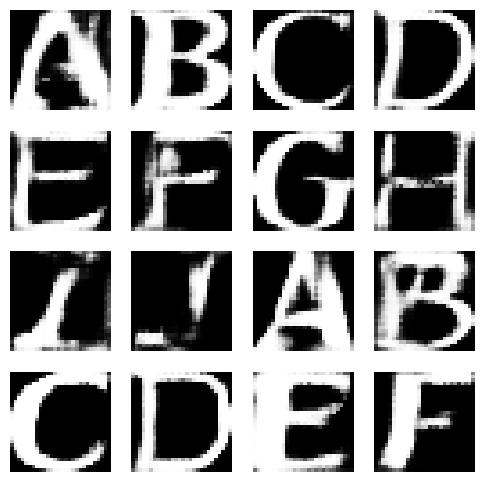

In [ ]:
# Load the saved samples
with open('train_samples.pkl', 'rb') as f:
    samples = pkl.load(f)

# Pick an epoch to visualize
epoch_samples = samples[-1]

# Show first 16 images
fig, axes = plt.subplots(4, 4, figsize=(6,6))
for img, ax in zip(epoch_samples, axes.flatten()):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.axis('off')
plt.show()


### Plotting Training Losses

We can visualize how the **discriminator** and **generator** losses evolve during training:

- `losses` is a list of tuples `(d_loss, g_loss)` recorded during training.  




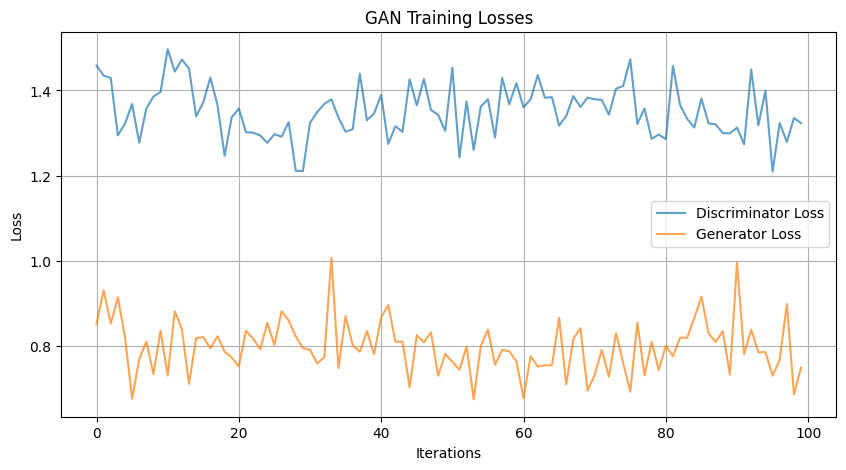

In [ ]:
# losses is a list of tuples: (d_loss, g_loss)
d_losses, g_losses = zip(*losses)

plt.figure(figsize=(10, 5))
plt.plot(d_losses, label='Discriminator Loss', alpha=0.7)
plt.plot(g_losses, label='Generator Loss', alpha=0.7)
plt.title('GAN Training Losses')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


### Generating Multiple Samples per Class

Using the trained generator, we can create several images per class:

- Generate 4 images for each of the 10 classes (0–9) by feeding random noise and class labels to the generator.  
- Denormalize images from `[-1,1]` to `[0,1]` for display.  
- Arrange the images in a grid where each row corresponds to a class, showing multiple generated examples.  

This allows visual inspection of the generator’s ability to produce **diverse, class-specific images**.


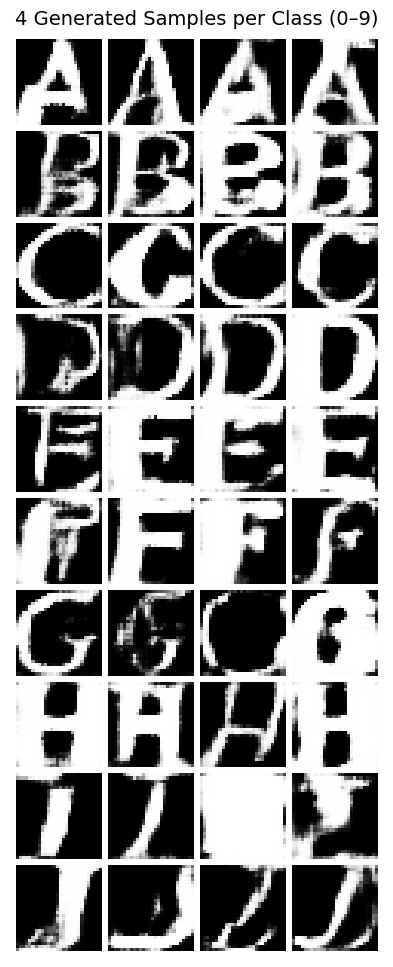

In [ ]:
from torchvision import utils

# CONFIG
gen = generator  # trained generator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gen.to(device)
gen.eval()

z_dim = 100
n_classes = 10
n_per_class = 4  # 4 images per class

# Helper
def denormalize(images):
    return (images + 1) / 2  # [-1,1] → [0,1]

# Generate
all_images = []
all_labels = []

with torch.no_grad():
    for label in range(n_classes):
        z = torch.randn(n_per_class, z_dim, device=device)
        labels = torch.full((n_per_class,), label, dtype=torch.long, device=device)
        fake_imgs = gen(z, labels)
        all_images.append(fake_imgs)
        all_labels.extend([label] * n_per_class)

# Concatenate all 10×4 = 40 images into one batch
all_images = torch.cat(all_images, dim=0)
all_images = denormalize(all_images)

#  Grid
grid = utils.make_grid(all_images, nrow=n_per_class, normalize=False, pad_value=1.0)

plt.figure(figsize=(8, 12))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.title("4 Generated Samples per Class (0–9)", fontsize=14)
plt.show()


### Summary

### Part A: Variational Autoencoder

### Key Results

- **Training Performance:**  
  - Latent dimension = 20, trained for 50 epochs using Adam optimizer.  
  - Both training and test losses decreased over epochs (Train ≈ 100.54, Test ≈ 105.19), indicating stable convergence.

- **Image Reconstruction:**  
  - The VAE was able to reconstruct input images accurately.  
  - Reconstructions improved in clarity and detail as training progressed.

- **New Image Generation:**  
  - Sampling random latent vectors produced realistic, previously unseen notMNIST letters.  
  - Generated images reflected the diversity of the dataset.

- **Latent Space Interpolation:**  
  - Smooth transitions between letters were observed (e.g., C → F), demonstrating that the latent space captures semantic continuity.  

- **Insights:**  
  - The VAE learned a structured latent space suitable for reconstruction, generation, and interpolation.  
  


### Part B: Conditional GAN

### Key Results

**Dataset & Setup:**  
- **Dataset:** notMNIST (28×28 grayscale letters A–J, 10 classes).  
- **Hyperparameters:**  
  - Latent dimension (`z_size`) = 100  
  - Generator conv base (`g_conv_dim`) = 128  
  - Discriminator conv base (`d_conv_dim`) = 64  
  - Batch size and learning rate: Adam optimizer with `lr = 0.0002`, `beta1 = 0.5`, `beta2 = 0.999`.  

**Architecture:**  
- **Generator (Conditional):**  
  - Input: Noise vector + one-hot class label.  
  - Fully connected layer → deconvolution layers → `tanh` activation.  
  - Dropout added to stabilize training.  
- **Discriminator (Conditional):**  
  - Input: Image + one-hot class label (expanded to match image dimensions).  
  - Convolutional layers with Leaky ReLU + dropout.  
  - Output: Single real/fake score, conditioned on class label.  
- **Weight Initialization:** Normal distribution (mean=0, std=0.02) for conv/linear layers; biases set to 0.

**Loss Functions:**  
- **Discriminator:** Binary Cross-Entropy with logits. Real and fake losses guide the discriminator to distinguish real vs. generated images conditioned on labels.  
- **Generator:** Adversarial loss encourages producing images that the discriminator classifies as real.

**Training Observations:**  
- Training ran for **20 epochs**, losses fluctuated but remained stable:  
  - Discriminator: ~1.25–1.45  
  - Generator: ~0.65–0.85  
- No signs of mode collapse.  

**Generated Images:**  
- Generator successfully produces **class-specific images (A–J)** using label conditioning.  
- Multiple samples per class show diversity; letters are recognizable but slightly blurry.  
- Fixed noise + labels allow consistent monitoring of generator progress (`train_samples.pkl`).  

**Conclusion:**  
The Conditional GAN effectively learned the joint distribution of notMNIST images and their labels, demonstrating that conditioning on class labels improves control over generated outputs while maintaining diversity and recognizability.
